<a href="https://colab.research.google.com/github/deepakc0523/llm_fingerprint/blob/main/Machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fingerprint: An End-to-End Machine Learning Framework for LLM Fingerprinting Using Synthetic Data

## Notebook 01 — Feature Engineering

### Objective

This notebook performs feature engineering on two preprocessed datasets:

- **Fingerprint Dataset (Pipeline A)** – Fingerprint-preserving preprocessing
- **Traditional Dataset (Pipeline B)** – Traditional NLP preprocessing

The notebook converts textual data into multiple numerical feature representations for downstream machine learning.

---

### Feature Engineering Techniques

1. TF-IDF Features
2. Character N-Gram Features
3. Stylometric Features
4. Sentence Embeddings (MiniLM)

---

### Outputs

- TF-IDF feature matrices
- Character N-Gram feature matrices
- Stylometric feature matrices
- Sentence embedding matrices
- Feature metadata
- Saved vectorizers and transformers

---

### Research Goal

Evaluate which feature representation best captures the stylistic fingerprints of Large Language Models for multi-class classification.

In [2]:
# ==========================================================
# Install Required Libraries
# Run only once per Colab session
# ==========================================================

!pip -q install sentence-transformers
!pip -q install pyarrow
!pip -q install joblib
!pip -q install scipy

In [3]:
# ==========================================================
# Import Libraries
# ==========================================================

import os
import random
import warnings
import joblib
import numpy as np
import pandas as pd

from pathlib import Path

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer

# Sentence Embeddings
from sentence_transformers import SentenceTransformer

# Utilities
from scipy import sparse

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
# ==========================================================
# Global Configuration
# ==========================================================

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

print(f"Random Seed : {RANDOM_STATE}")

Random Seed : 42


In [6]:
# ==========================================================
# Upload Datasets
# ==========================================================

from google.colab import files

uploaded = files.upload()

print("\nUploaded Files:")
for file in uploaded.keys():
    print(file)

Saving merged_dataset.csv to merged_dataset.csv

Uploaded Files:
merged_dataset.csv


In [7]:
# ==========================================================
# Upload Datasets
# ==========================================================

from google.colab import files

uploaded = files.upload()

print("\nUploaded Files:")
for file in uploaded.keys():
    print(file)

Saving processed_dataset.csv to processed_dataset.csv

Uploaded Files:
processed_dataset.csv


In [8]:
# ==========================================================
# Upload Datasets
# ==========================================================

from google.colab import files

uploaded = files.upload()

print("\nUploaded Files:")
for file in uploaded.keys():
    print(file)

Saving processed_dataset(1).csv to processed_dataset(1).csv

Uploaded Files:
processed_dataset(1).csv


In [9]:
# ==========================================================
# Load Datasets
# ==========================================================

raw_df = pd.read_csv("merged_dataset.csv")

fingerprint_df = pd.read_csv("processed_dataset.csv")

traditional_df = pd.read_csv("processed_dataset(1).csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [10]:
# ==========================================================
# Dataset Summary
# ==========================================================

datasets = {
    "Raw Dataset": raw_df,
    "Fingerprint Dataset": fingerprint_df,
    "Traditional Dataset": traditional_df
}

for name, df in datasets.items():

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(f"Rows    : {df.shape[0]}")
    print(f"Columns : {df.shape[1]}")

    print("\nColumns")
    print(df.columns.tolist())

    print()

Raw Dataset
Rows    : 5240
Columns : 14

Columns
['prefix_id', 'dataset_name', 'category', 'human_prefix', 'generated_text', 'model_name', 'temperature', 'top_p', 'max_new_tokens', 'prompt_length', 'completion_length', 'generation_time', 'timestamp', 'model_label']

Fingerprint Dataset
Rows    : 5238
Columns : 16

Columns
['prefix_id', 'dataset_name', 'category', 'human_prefix', 'generated_text', 'model_name', 'temperature', 'top_p', 'max_new_tokens', 'prompt_length', 'completion_length', 'generation_time', 'timestamp', 'model_label', 'char_length', 'word_count']

Traditional Dataset
Rows    : 5238
Columns : 16

Columns
['prefix_id', 'dataset_name', 'category', 'human_prefix', 'generated_text', 'model_name', 'temperature', 'top_p', 'max_new_tokens', 'prompt_length', 'completion_length', 'generation_time', 'timestamp', 'model_label', 'char_length', 'word_count']



In [11]:
# ==========================================================
# Preview Datasets
# ==========================================================

display(raw_df.head())

display(fingerprint_df.head())

display(traditional_df.head())

,prefix_id,dataset_name,category,human_prefix,generated_text,model_name,temperature,top_p,max_new_tokens,prompt_length,completion_length,generation_time,timestamp,model_label
0,6cf19050-5d46-46c4-9fd6-fbe62c41a066,stackexchange,technical_qa,"Here is my current bed levelling mesh:</p>\n<p><a href=""https://i.stack.imgur.com/kepvq.png"" rel=""nofollow noreferrer""><img src=""https://i.stack.imgur.com/kepvq.","The correct answer is: <a href=""https://i.stack.imgur.com/kepvq.png"" rel=""nofollow noreferrer"">https://i.stack.imgur.com/kepvq.png</a></p>\n\nI have been trying to locate the correct answer but I...",qwen_tiny,0.7,0.9,128,160,493,0.064535,2026-07-21T15:47:25Z,qwen_tiny
1,0645cd1e-9728-4a75-9268-79f0b4f3fc44,stackexchange,technical_qa,"noreferrer"">WhamBam build system</a> on order. A magnet attaches (glues down I think) to the Aluminium printing bed (or add a glass sheet? Separate question), then PEX material on flexible steel ...","<p> <strong>What is the build process?</strong> First you get a print sheet and print the pattern on it, then use a magnet to attach it to the bed. Then you print the material on the magnet and i...",qwen_tiny,0.7,0.9,128,248,518,0.064535,2026-07-21T15:47:25Z,qwen_tiny
2,c2b3166e-b685-486c-9e7e-ec6a49058692,stackexchange,technical_qa,"wp-content/uploads/2015/07/Dualprint-3DBenchy-Main-image-Dual.jpg"" rel=""nofollow noreferrer"">dual-colour pic on the Benchy website</a> looks way better, so I don't think it's just that these parts",are being printed on the benchy website. I think it's just that the two parts are being printed on the benchy website and it looks way better. I don't think it's just that these parts are being p...,llama3,0.7,0.9,64,196,283,0.135466,2026-07-26T14:12:28Z,llama3
3,32715959-43ea-4022-b926-eddd90412c2b,gutenberg,literature,on for a very special night. Thanks Bobby at Epic for making it such a great night!!!”\n- “The photobooth was absolutely amazing! My friends complimented that it was the best idea ever and the se...,", the customers were very happy with their experience. I will be back again! Thanks Epic for the great experience!”\n- “The photobooth was amazing! It was a great way to capture the fun moments wi...",qwen_tiny,0.7,0.9,128,285,583,0.061996,2026-07-21T15:51:30Z,qwen_tiny
4,20133792-b7b4-4837-a29e-8c052f7960bd,stackexchange,technical_qa,"'re already in the right places in the STL files, so I just want to import them and go.)</p>\n\n<p><strong>Edit</strong> I've accepted Trish's answer (use Blender), but I'd still appreciate a comm...","\n\nI'm working with 3D printing and am trying to import STL files. I'm curious if there's a command-line option in Blender for this. I know you can import them from the UI, but I'm looking for so...",gemma2,0.7,0.9,64,234,239,0.000000,2026-07-26T15:14:01Z,gemma2


,prefix_id,dataset_name,category,human_prefix,generated_text,model_name,temperature,top_p,max_new_tokens,prompt_length,completion_length,generation_time,timestamp,model_label,char_length,word_count
0,6cf19050-5d46-46c4-9fd6-fbe62c41a066,stackexchange,technical_qa,"Here is my current bed levelling mesh:</p>\n<p><a href=""https://i.stack.imgur.com/kepvq.png"" rel=""nofollow noreferrer""><img src=""https://i.stack.imgur.com/kepvq.","The correct answer is: <a href=""https://i.stack.imgur.com/kepvq.png"" rel=""nofollow noreferrer"">https://i.stack.imgur.com/kepvq.png</a></p>\n\nI have been trying to locate the correct answer but I ...",qwen_tiny,0.7,0.9,128,160,493,0.064535,2026-07-21T15:47:25Z,qwen_tiny,491,73
1,0645cd1e-9728-4a75-9268-79f0b4f3fc44,stackexchange,technical_qa,"noreferrer"">WhamBam build system</a> on order. A magnet attaches (glues down I think) to the Aluminium printing bed (or add a glass sheet? Separate question), then PEX material on flexible steel s...","<p> <strong>What is the build process?</strong> First you get a print sheet and print the pattern on it, then use a magnet to attach it to the bed. Then you print the material on the magnet and it...",qwen_tiny,0.7,0.9,128,248,518,0.064535,2026-07-21T15:47:25Z,qwen_tiny,517,97
2,c2b3166e-b685-486c-9e7e-ec6a49058692,stackexchange,technical_qa,"wp-content/uploads/2015/07/Dualprint-3DBenchy-Main-image-Dual.jpg"" rel=""nofollow noreferrer"">dual-colour pic on the Benchy website</a> looks way better, so I don't think it's just that these parts",are being printed on the benchy website. I think it's just that the two parts are being printed on the benchy website and it looks way better. I don't think it's just that these parts are being pr...,llama3,0.7,0.9,64,196,283,0.135466,2026-07-26T14:12:28Z,llama3,282,54
3,32715959-43ea-4022-b926-eddd90412c2b,gutenberg,literature,on for a very special night. Thanks Bobby at Epic for making it such a great night!!!”\n- “The photobooth was absolutely amazing! My friends complimented that it was the best idea ever and the ser...,", the customers were very happy with their experience. I will be back again! Thanks Epic for the great experience!”\n- “The photobooth was amazing! It was a great way to capture the fun moments wi...",qwen_tiny,0.7,0.9,128,285,583,0.061996,2026-07-21T15:51:30Z,qwen_tiny,583,109
4,20133792-b7b4-4837-a29e-8c052f7960bd,stackexchange,technical_qa,"'re already in the right places in the STL files, so I just want to import them and go.)</p>\n\n<p><strong>Edit</strong> I've accepted Trish's answer (use Blender), but I'd still appreciate a comm...","I'm working with 3D printing and am trying to import STL files. I'm curious if there's a command-line option in Blender for this. I know you can import them from the UI, but I'm looking for someth...",gemma2,0.7,0.9,64,234,239,0.000000,2026-07-26T15:14:01Z,gemma2,237,44


,prefix_id,dataset_name,category,human_prefix,generated_text,model_name,temperature,top_p,max_new_tokens,prompt_length,completion_length,generation_time,timestamp,model_label,char_length,word_count
0,6cf19050-5d46-46c4-9fd6-fbe62c41a066,stackexchange,technical_qa,current bed levelling meshp pa hrefhttpsistackimgurcomkepvqpng relnofollow noreferrerimg srchttpsistackimgurcomkepvq,correct answer hrefhttpsistackimgurcomkepvqpng relnofollow noreferrerhttpsistackimgurcomkepvqpngap trying locate correct answer sure can help appreciate explain detail yes can help answer provided...,qwen_tiny,0.7,0.9,128,160,493,0.064535,2026-07-21T15:47:25Z,qwen_tiny,267,27
1,0645cd1e-9728-4a75-9268-79f0b4f3fc44,stackexchange,technical_qa,noreferrerwhambam build systema order magnet attache glue think aluminium printing bed add glass sheet separate question pex material flexible steel sheet get slapped print surface p,p strongwhat build processstrong first get print sheet print pattern use magnet attach bed print material magnet done p p strongis good buildstrong think good build print surface quite durable loo...,qwen_tiny,0.7,0.9,128,248,518,0.064535,2026-07-21T15:47:25Z,qwen_tiny,311,48
2,c2b3166e-b685-486c-9e7e-ec6a49058692,stackexchange,technical_qa,wpcontentuploads201507dualprint3dbenchymainimagedualjpg relnofollow noreferrerdualcolour pic benchy websitea look way better don think just part,printed benchy website think just two part printed benchy website look way better don think just part printed benchy website think just two part printed,llama3,0.7,0.9,64,196,283,0.135466,2026-07-26T14:12:28Z,llama3,152,25
3,32715959-43ea-4022-b926-eddd90412c2b,gutenberg,literature,special night thanks bobby epic making great night” “the photobooth absolutely amazing friend complimented best idea ever service incredible guy totally cool super nice even though raining,customer happy experience will back thanks epic great experience” “the photobooth amazing great way capture fun moment friend nice way share memory service super fast people friendly will back tha...,qwen_tiny,0.7,0.9,128,285,583,0.061996,2026-07-21T15:51:30Z,qwen_tiny,345,51
4,20133792-b7b4-4837-a29e-8c052f7960bd,stackexchange,technical_qa,re already right place stl file just want import gop pstrongeditstrong accepted trish answer use blender still appreciate commandline option anyone know onep,working 3d printing trying import stl file curious commandline option blender know can import ui looking something can run terminalp let,gemma2,0.7,0.9,64,234,239,0.000000,2026-07-26T15:14:01Z,gemma2,136,21


In [12]:
# ==========================================================
# Validate Datasets
# ==========================================================

def validate_dataset(df, name):

    print("=" * 60)
    print(name)
    print("=" * 60)

    print("Shape:", df.shape)

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nDuplicate Rows:", df.duplicated().sum())

    print("\nData Types")
    print(df.dtypes)

    print("\nClass Distribution")

    if "model_label" in df.columns:
        print(df["model_label"].value_counts())

    print()

validate_dataset(raw_df, "Raw Dataset")

validate_dataset(fingerprint_df, "Fingerprint Dataset")

validate_dataset(traditional_df, "Traditional Dataset")

Raw Dataset
Shape: (5240, 14)

Missing Values
prefix_id            0
dataset_name         0
category             0
human_prefix         0
generated_text       1
model_name           0
temperature          0
top_p                0
max_new_tokens       0
prompt_length        0
completion_length    0
generation_time      0
timestamp            0
model_label          0
dtype: int64

Duplicate Rows: 0

Data Types
prefix_id             object
dataset_name          object
category              object
human_prefix          object
generated_text        object
model_name            object
temperature          float64
top_p                float64
max_new_tokens         int64
prompt_length          int64
completion_length      int64
generation_time      float64
timestamp             object
model_label           object
dtype: object

Class Distribution
model_label
qwen_tiny    1256
gemma2       1000
mistral      1000
phi3         1000
llama3        984
Name: count, dtype: int64

Fingerprint Dataset

In [13]:
# ==========================================================
# Verify Required Columns
# ==========================================================

required_columns = [
    "generated_text",
    "model_label"
]

for name, df in datasets.items():

    missing = [
        col for col in required_columns
        if col not in df.columns
    ]

    if len(missing) == 0:
        print(f"✓ {name} : All required columns present.")

    else:
        print(f"✗ {name} : Missing columns -> {missing}")

✓ Raw Dataset : All required columns present.
✓ Fingerprint Dataset : All required columns present.
✓ Traditional Dataset : All required columns present.


# Part A – TF-IDF Feature Engineering

## Objective

Convert the textual responses into sparse TF-IDF feature vectors.

TF-IDF highlights terms that are important within a document while reducing the influence of extremely common words.

This serves as the first feature representation for LLM fingerprint classification.

In [14]:
# ==========================================================
# TF-IDF Configuration
# ==========================================================

TFIDF_CONFIG = {

    # Maximum vocabulary size
    "max_features": 10000,

    # Ignore extremely rare words
    "min_df": 2,

    # Ignore extremely common words
    "max_df": 0.95,

    # Unigrams + Bigrams
    "ngram_range": (1, 2),

    # L2 normalization
    "norm": "l2",

    # Sublinear TF scaling
    "sublinear_tf": True,

    # Keep case (important for fingerprinting)
    "lowercase": False
}

print(TFIDF_CONFIG)

{'max_features': 10000, 'min_df': 2, 'max_df': 0.95, 'ngram_range': (1, 2), 'norm': 'l2', 'sublinear_tf': True, 'lowercase': False}


In [15]:
# ==========================================================
# Create TF-IDF Vectorizer
# ==========================================================

tfidf_vectorizer = TfidfVectorizer(
    **TFIDF_CONFIG
)

print(tfidf_vectorizer)

TfidfVectorizer(lowercase=False, max_df=0.95, max_features=10000, min_df=2,
                ngram_range=(1, 2), sublinear_tf=True)


In [16]:
# ==========================================================
# Fingerprint Dataset
# TF-IDF Features
# ==========================================================

X_fingerprint_tfidf = tfidf_vectorizer.fit_transform(
    fingerprint_df["generated_text"]
)

y_fingerprint = fingerprint_df["model_label"]

print("Fingerprint TF-IDF Shape")

print(X_fingerprint_tfidf.shape)

Fingerprint TF-IDF Shape
(5238, 10000)


In [17]:
# ==========================================================
# Traditional Dataset
# TF-IDF Features
# ==========================================================

X_traditional_tfidf = tfidf_vectorizer.transform(
    traditional_df["generated_text"]
)

y_traditional = traditional_df["model_label"]

print("Traditional TF-IDF Shape")

print(X_traditional_tfidf.shape)

Traditional TF-IDF Shape
(5238, 10000)


In [18]:
# ==========================================================
# Vocabulary Information
# ==========================================================

feature_names = tfidf_vectorizer.get_feature_names_out()

print("Vocabulary Size")

print(len(feature_names))

print("\nFirst 30 Features\n")

print(feature_names[:30])

Vocabulary Size
10000

First 30 Features

['00' '000' '000 ASL' '000 people' '01' '0138' '0140' '0148' '03' '04'
 '05' '09' '10' '10 000' '10 in' '10 million' '10 year' '10 years' '100'
 '100 li' '100 million' '1000' '10000000' '100m' '10th' '11' '110' '12'
 '120' '1200']


In [19]:
# ==========================================================
# TF-IDF Statistics
# ==========================================================

print("=" * 60)
print("Fingerprint Dataset")
print("=" * 60)

print("Shape :", X_fingerprint_tfidf.shape)

print("Non-zero values :", X_fingerprint_tfidf.nnz)

print("Density :",
      X_fingerprint_tfidf.nnz /
      (
          X_fingerprint_tfidf.shape[0] *
          X_fingerprint_tfidf.shape[1]
      )
)

print()

print("=" * 60)
print("Traditional Dataset")
print("=" * 60)

print("Shape :", X_traditional_tfidf.shape)

print("Non-zero values :", X_traditional_tfidf.nnz)

print("Density :",
      X_traditional_tfidf.nnz /
      (
          X_traditional_tfidf.shape[0] *
          X_traditional_tfidf.shape[1]
      )
)

Fingerprint Dataset
Shape : (5238, 10000)
Non-zero values : 275045
Density : 0.005250954562810233

Traditional Dataset
Shape : (5238, 10000)
Non-zero values : 96341
Density : 0.001839270714012982


In [20]:
# ==========================================================
# Create Output Directory
# ==========================================================

OUTPUT_DIR = "features"

os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(
    tfidf_vectorizer,
    os.path.join(OUTPUT_DIR, "tfidf_vectorizer.pkl")
)

sparse.save_npz(
    os.path.join(
        OUTPUT_DIR,
        "fingerprint_tfidf.npz"
    ),
    X_fingerprint_tfidf
)

sparse.save_npz(
    os.path.join(
        OUTPUT_DIR,
        "traditional_tfidf.npz"
    ),
    X_traditional_tfidf
)

joblib.dump(
    y_fingerprint,
    os.path.join(
        OUTPUT_DIR,
        "fingerprint_labels.pkl"
    )
)

joblib.dump(
    y_traditional,
    os.path.join(
        OUTPUT_DIR,
        "traditional_labels.pkl"
    )
)

print("TF-IDF Features Saved Successfully")

TF-IDF Features Saved Successfully


In [21]:
# ==========================================================
# TF-IDF Summary
# ==========================================================

print("=" * 60)
print("TF-IDF Feature Engineering Completed")
print("=" * 60)

print(f"Vocabulary Size : {len(feature_names)}")

print(f"Fingerprint Shape : {X_fingerprint_tfidf.shape}")

print(f"Traditional Shape : {X_traditional_tfidf.shape}")

print("\nSaved Files")

print("- tfidf_vectorizer.pkl")
print("- fingerprint_tfidf.npz")
print("- traditional_tfidf.npz")
print("- fingerprint_labels.pkl")
print("- traditional_labels.pkl")

TF-IDF Feature Engineering Completed
Vocabulary Size : 10000
Fingerprint Shape : (5238, 10000)
Traditional Shape : (5238, 10000)

Saved Files
- tfidf_vectorizer.pkl
- fingerprint_tfidf.npz
- traditional_tfidf.npz
- fingerprint_labels.pkl
- traditional_labels.pkl


# Part B – TF-IDF Feature Analysis

## Objective

Analyze the characteristics of the TF-IDF feature representations generated from:

- Fingerprint Dataset (Pipeline A)
- Traditional Dataset (Pipeline B)

This section quantifies how different preprocessing pipelines affect the richness and sparsity of textual feature representations.

The results generated here will be used later to interpret machine learning performance.

In [22]:
# ==========================================================
# Average Document Statistics
# ==========================================================

def document_statistics(df, name):

    words = df["generated_text"].astype(str).str.split()

    word_count = words.apply(len)

    unique_words = words.apply(lambda x: len(set(x)))

    stats = {
        "Dataset": name,
        "Documents": len(df),
        "Average Words": word_count.mean(),
        "Median Words": word_count.median(),
        "Minimum Words": word_count.min(),
        "Maximum Words": word_count.max(),
        "Average Unique Words": unique_words.mean()
    }

    return stats


fingerprint_stats = document_statistics(
    fingerprint_df,
    "Fingerprint"
)

traditional_stats = document_statistics(
    traditional_df,
    "Traditional"
)

stats_df = pd.DataFrame([
    fingerprint_stats,
    traditional_stats
])

display(stats_df)

,Dataset,Documents,Average Words,Median Words,Minimum Words,Maximum Words,Average Unique Words
0,Fingerprint,5238,63.102138,53.0,1,123,43.126575
1,Traditional,5238,33.588583,29.0,1,93,25.602711


In [23]:
# ==========================================================
# Active TF-IDF Features
# ==========================================================

fingerprint_active = np.asarray(
    (X_fingerprint_tfidf != 0).sum(axis=1)
).flatten()

traditional_active = np.asarray(
    (X_traditional_tfidf != 0).sum(axis=1)
).flatten()

active_df = pd.DataFrame({

    "Dataset": [
        "Fingerprint",
        "Traditional"
    ],

    "Average Active Features": [
        fingerprint_active.mean(),
        traditional_active.mean()
    ],

    "Median Active Features": [
        np.median(fingerprint_active),
        np.median(traditional_active)
    ],

    "Maximum Active Features": [
        fingerprint_active.max(),
        traditional_active.max()
    ]
})

display(active_df)

,Dataset,Average Active Features,Median Active Features,Maximum Active Features
0,Fingerprint,52.509546,49.0,125
1,Traditional,18.392707,17.0,49


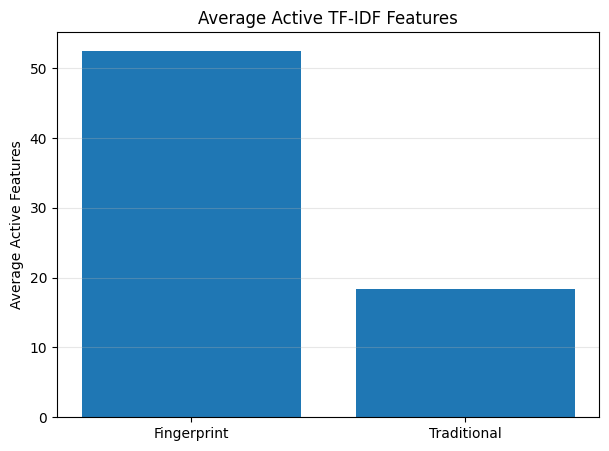

In [24]:
# ==========================================================
# Visual Comparison
# ==========================================================

import matplotlib.pyplot as plt

metrics = [

    fingerprint_active.mean(),
    traditional_active.mean()

]

labels = [

    "Fingerprint",
    "Traditional"

]

plt.figure(figsize=(7,5))

plt.bar(labels, metrics)

plt.title("Average Active TF-IDF Features")

plt.ylabel("Average Active Features")

plt.grid(axis="y", alpha=0.3)

plt.show()

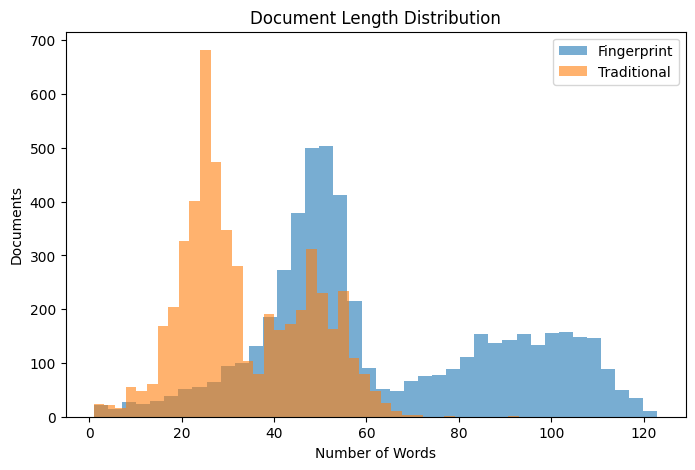

In [25]:
# ==========================================================
# Document Length Distribution
# ==========================================================

plt.figure(figsize=(8,5))

plt.hist(

    fingerprint_df["generated_text"].str.split().apply(len),

    bins=40,

    alpha=0.6,

    label="Fingerprint"

)

plt.hist(

    traditional_df["generated_text"].str.split().apply(len),

    bins=40,

    alpha=0.6,

    label="Traditional"

)

plt.xlabel("Number of Words")

plt.ylabel("Documents")

plt.title("Document Length Distribution")

plt.legend()

plt.show()

In [26]:
# ==========================================================
# Sparsity Analysis
# ==========================================================

def sparsity(matrix):

    total = matrix.shape[0] * matrix.shape[1]

    nonzero = matrix.nnz

    sparse_percent = (
        1 -
        nonzero / total
    ) * 100

    return sparse_percent


sparsity_df = pd.DataFrame({

    "Dataset":[
        "Fingerprint",
        "Traditional"
    ],

    "Sparsity (%)":[

        sparsity(X_fingerprint_tfidf),

        sparsity(X_traditional_tfidf)

    ]

})

display(sparsity_df)

,Dataset,Sparsity (%)
0,Fingerprint,99.474905
1,Traditional,99.816073


In [27]:
# ==========================================================
# Vocabulary Coverage
# ==========================================================

fingerprint_vocab = set()

for text in fingerprint_df["generated_text"].astype(str):

    fingerprint_vocab.update(text.split())

traditional_vocab = set()

for text in traditional_df["generated_text"].astype(str):

    traditional_vocab.update(text.split())

coverage = pd.DataFrame({

    "Dataset":[
        "Fingerprint",
        "Traditional"
    ],

    "Unique Words":[
        len(fingerprint_vocab),
        len(traditional_vocab)
    ],

    "Vocabulary Reduction (%)":[
        0,
        (
            1 -
            len(traditional_vocab) /
            len(fingerprint_vocab)
        ) * 100
    ]
})

display(coverage)

,Dataset,Unique Words,Vocabulary Reduction (%)
0,Fingerprint,38631,0.000000
1,Traditional,20215,47.671559


In [28]:
# ==========================================================
# Automatic Research Interpretation
# ==========================================================

print("="*70)
print("RESEARCH OBSERVATIONS")
print("="*70)

ratio = fingerprint_active.mean() / traditional_active.mean()

print(f"\n1. The Fingerprint pipeline retains approximately {ratio:.2f}× more active TF-IDF features than the Traditional pipeline.")

reduction = coverage.loc[1, "Vocabulary Reduction (%)"]

print(f"\n2. Traditional preprocessing reduces the vocabulary by approximately {reduction:.2f}% compared with the Fingerprint pipeline.")

print(f"\n3. TF-IDF sparsity:")
print(f"   Fingerprint : {sparsity(X_fingerprint_tfidf):.2f}%")
print(f"   Traditional : {sparsity(X_traditional_tfidf):.2f}%")

print("\n4. Both datasets share an identical feature space (10,000 dimensions), ensuring a fair comparison in subsequent machine learning experiments.")

print("\n5. These observations will be validated in the classification stage to determine whether richer stylistic information translates into improved LLM fingerprinting performance.")

RESEARCH OBSERVATIONS

1. The Fingerprint pipeline retains approximately 2.85× more active TF-IDF features than the Traditional pipeline.

2. Traditional preprocessing reduces the vocabulary by approximately 47.67% compared with the Fingerprint pipeline.

3. TF-IDF sparsity:
   Fingerprint : 99.47%
   Traditional : 99.82%

4. Both datasets share an identical feature space (10,000 dimensions), ensuring a fair comparison in subsequent machine learning experiments.

5. These observations will be validated in the classification stage to determine whether richer stylistic information translates into improved LLM fingerprinting performance.


# Part C – Character N-Gram Features

Character N-grams capture stylistic writing patterns such as punctuation, spacing, prefixes, suffixes, capitalization, and formatting. These features are particularly useful for LLM fingerprinting because they are less dependent on semantics and more reflective of generation style.

CHARACTER N-GRAM SUMMARY
Vocabulary Size          : 15000
Fingerprint Shape        : (5238, 15000)
Traditional Shape        : (5238, 15000)
Fingerprint Avg Features : 555.19
Traditional Avg Features : 339.33


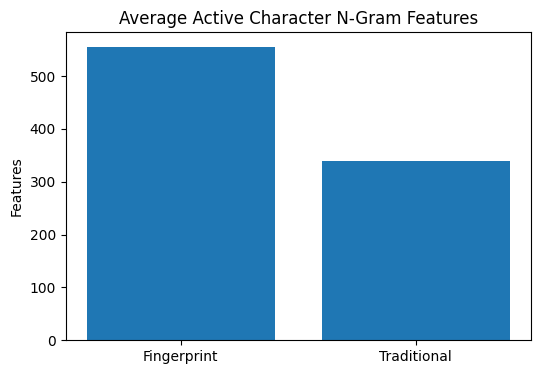


Character N-Gram Features Saved Successfully


In [29]:
# ==========================================================
# CHARACTER N-GRAM FEATURE EXTRACTION
# ==========================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy import sparse
import matplotlib.pyplot as plt
import joblib
import os

# Configuration
CHAR_CONFIG = {
    "analyzer": "char",
    "ngram_range": (3, 5),
    "max_features": 15000,
    "min_df": 2,
    "sublinear_tf": True,
    "lowercase": False
}

char_vectorizer = TfidfVectorizer(**CHAR_CONFIG)

# Feature Extraction
X_fingerprint_char = char_vectorizer.fit_transform(
    fingerprint_df["generated_text"]
)

X_traditional_char = char_vectorizer.transform(
    traditional_df["generated_text"]
)

# Labels
y_fingerprint = fingerprint_df["model_label"]
y_traditional = traditional_df["model_label"]

# Statistics
fp_active = np.asarray((X_fingerprint_char != 0).sum(axis=1)).flatten()
tr_active = np.asarray((X_traditional_char != 0).sum(axis=1)).flatten()

print("="*70)
print("CHARACTER N-GRAM SUMMARY")
print("="*70)
print(f"Vocabulary Size          : {len(char_vectorizer.get_feature_names_out())}")
print(f"Fingerprint Shape        : {X_fingerprint_char.shape}")
print(f"Traditional Shape        : {X_traditional_char.shape}")
print(f"Fingerprint Avg Features : {fp_active.mean():.2f}")
print(f"Traditional Avg Features : {tr_active.mean():.2f}")

# Visualization
plt.figure(figsize=(6,4))
plt.bar(
    ["Fingerprint","Traditional"],
    [fp_active.mean(), tr_active.mean()]
)
plt.title("Average Active Character N-Gram Features")
plt.ylabel("Features")
plt.show()

# Save
sparse.save_npz("features/fingerprint_char_ngrams.npz", X_fingerprint_char)
sparse.save_npz("features/traditional_char_ngrams.npz", X_traditional_char)
joblib.dump(char_vectorizer, "features/char_vectorizer.pkl")

print("\nCharacter N-Gram Features Saved Successfully")

# Part D – Stylometric Features

Stylometric features quantify writing style rather than meaning. They include statistics such as sentence length, punctuation usage, lexical diversity, capitalization, and digit frequency. These are widely used in authorship attribution and are well suited for LLM fingerprinting.

In [30]:
# ==========================================================
# STYLOMETRIC FEATURE EXTRACTION
# ==========================================================

import re
import string

def stylometric_features(text):

    text = str(text)

    words = text.split()

    chars = len(text)

    return [

        len(words),                                              # Word Count
        chars,                                                   # Character Count
        np.mean([len(w) for w in words]) if words else 0,        # Avg Word Length
        len(set(words))/len(words) if words else 0,              # Lexical Diversity
        sum(c.isupper() for c in text),                          # Uppercase Count
        sum(c.isdigit() for c in text),                          # Digit Count
        sum(c in string.punctuation for c in text),              # Punctuation Count
        text.count(","),                                         # Commas
        text.count("."),                                         # Periods
        text.count("?"),                                         # Questions
        text.count("!"),                                         # Exclamations
        len(re.findall(r"\n", text)),                            # New Lines
        text.count('"'),                                         # Quotes
        len(re.findall(r"\s", text))                             # Whitespaces
    ]

X_fingerprint_style = np.array(
    fingerprint_df["generated_text"].apply(stylometric_features).tolist()
)

X_traditional_style = np.array(
    traditional_df["generated_text"].apply(stylometric_features).tolist()
)

feature_names = [

    "Word Count",
    "Character Count",
    "Average Word Length",
    "Lexical Diversity",
    "Uppercase",
    "Digits",
    "Punctuation",
    "Comma",
    "Period",
    "Question",
    "Exclamation",
    "Newline",
    "Quotes",
    "Whitespace"
]

summary = pd.DataFrame({

    "Feature": feature_names,

    "Fingerprint Mean": X_fingerprint_style.mean(axis=0),

    "Traditional Mean": X_traditional_style.mean(axis=0)

})

display(summary)

np.save("features/fingerprint_style.npy", X_fingerprint_style)
np.save("features/traditional_style.npy", X_traditional_style)

print("\nStylometric Features Saved Successfully")

,Feature,Fingerprint Mean,Traditional Mean
0,Word Count,63.102138,33.588583
1,Character Count,371.946163,242.357579
2,Average Word Length,5.366364,6.586259
3,Lexical Diversity,0.714803,0.787687
4,Uppercase,11.765750,0.000000
5,Digits,3.923253,3.923253
6,Punctuation,15.690149,0.000000
7,Comma,3.140321,0.000000
8,Period,3.871325,0.000000
9,Question,0.159030,0.000000



Stylometric Features Saved Successfully


# Part E – Sentence Embeddings

Sentence embeddings encode each document into a dense semantic vector using the all-MiniLM-L6-v2 model. This provides a modern semantic representation that complements lexical and stylistic features.

In [31]:
# ==========================================================
# SENTENCE EMBEDDINGS
# ==========================================================

from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

X_fingerprint_embed = embedding_model.encode(

    fingerprint_df["generated_text"].tolist(),

    batch_size=64,

    show_progress_bar=True,

    convert_to_numpy=True

)

X_traditional_embed = embedding_model.encode(

    traditional_df["generated_text"].tolist(),

    batch_size=64,

    show_progress_bar=True,

    convert_to_numpy=True

)

print("="*70)
print("SENTENCE EMBEDDINGS SUMMARY")
print("="*70)

print("Fingerprint :", X_fingerprint_embed.shape)

print("Traditional :", X_traditional_embed.shape)

np.save(
    "features/fingerprint_embeddings.npy",
    X_fingerprint_embed
)

np.save(
    "features/traditional_embeddings.npy",
    X_traditional_embed
)

print("\nSentence Embeddings Saved Successfully")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/82 [00:00<?, ?it/s]

Batches:   0%|          | 0/82 [00:00<?, ?it/s]

SENTENCE EMBEDDINGS SUMMARY
Fingerprint : (5238, 384)
Traditional : (5238, 384)

Sentence Embeddings Saved Successfully


# Dataset Description

## Objective

This study aims to identify the originating Large Language Model (LLM) from generated text using classical machine learning and natural language processing techniques.

### Dataset Construction

The dataset consists of synthetic text generated by five instruction-tuned Large Language Models:

- Gemma 2
- Llama 3
- Mistral
- Phi 3
- Qwen

Each document contains one generated response together with its corresponding model label.

The complete corpus initially exists as a raw merged dataset (`merged_dataset.csv`). Two preprocessing pipelines are then applied:

### Pipeline A – Fingerprint Preserving

The fingerprint-preserving pipeline intentionally retains stylistic characteristics of the generated text including punctuation, capitalization, spacing, contractions, and formatting.

This pipeline aims to preserve author-specific writing patterns that may help distinguish different language models.

### Pipeline B – Traditional NLP

The traditional preprocessing pipeline applies conventional NLP normalization techniques such as lower-level text normalization and removal of stylistically irrelevant information.

Its objective is to produce a cleaner lexical representation for comparison with the fingerprint-preserving pipeline.

The processed datasets are subsequently transformed into four different feature representations:

- TF-IDF
- Character N-Grams
- Stylometric Features
- Sentence Embeddings

These feature representations are evaluated independently using multiple classical machine learning classifiers.


Fingerprint Dataset
Documents                 : 5238
Missing Values            : 0
Empty Documents           : (text.str.strip()=='').sum()
Duplicate Documents       : 367

Average Length            : 63.10
Median Length             : 53.00
Minimum Length            : 1
Maximum Length            : 123

Very Short (<10 words)    : 54
Very Long (>300 words)    : 0
Vocabulary Size           : 38631

Label Distribution


,count
model_label,
qwen_tiny,1256
phi3,1000
mistral,1000
gemma2,999
llama3,983


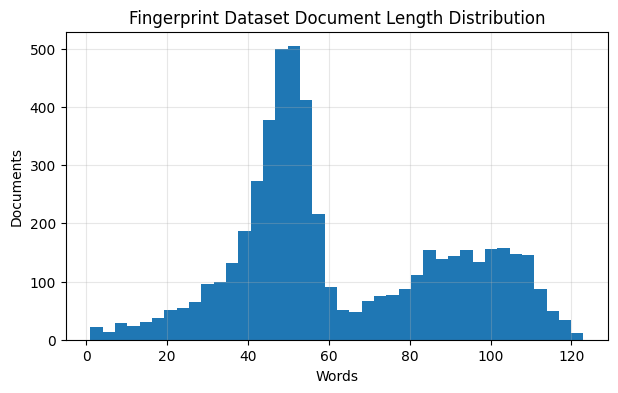


Traditional Dataset
Documents                 : 5238
Missing Values            : 0
Empty Documents           : (text.str.strip()=='').sum()
Duplicate Documents       : 368

Average Length            : 33.59
Median Length             : 29.00
Minimum Length            : 1
Maximum Length            : 93

Very Short (<10 words)    : 102
Very Long (>300 words)    : 0
Vocabulary Size           : 20215

Label Distribution


,count
model_label,
qwen_tiny,1256
phi3,1000
mistral,1000
gemma2,999
llama3,983


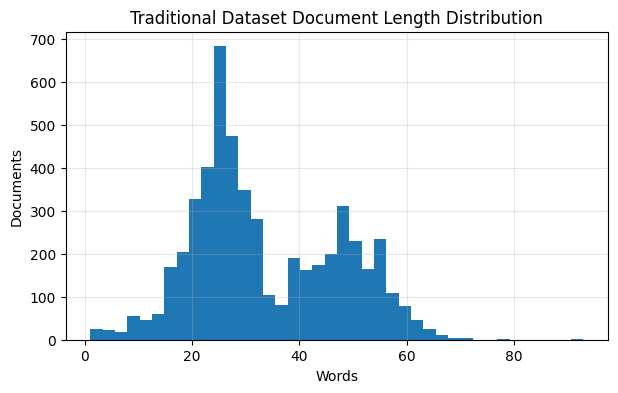

In [32]:
# ==========================================================
# DATASET QUALITY ASSESSMENT
# ==========================================================

import matplotlib.pyplot as plt

def quality_report(df, name):

    print("\n" + "="*80)
    print(name)
    print("="*80)

    text = df["generated_text"].astype(str)

    lengths = text.str.split().apply(len)

    print(f"Documents                 : {len(df)}")
    print(f"Missing Values            : {text.isnull().sum()}")
    print(f"Empty Documents           : (text.str.strip()=='').sum()")
    print(f"Duplicate Documents       : {text.duplicated().sum()}")

    print(f"\nAverage Length            : {lengths.mean():.2f}")
    print(f"Median Length             : {lengths.median():.2f}")
    print(f"Minimum Length            : {lengths.min()}")
    print(f"Maximum Length            : {lengths.max()}")

    short_docs = (lengths < 10).sum()
    long_docs = (lengths > 300).sum()

    print(f"\nVery Short (<10 words)    : {short_docs}")
    print(f"Very Long (>300 words)    : {long_docs}")

    vocab = set()

    for doc in text:
        vocab.update(doc.split())

    print(f"Vocabulary Size           : {len(vocab)}")

    print("\nLabel Distribution")

    display(df["model_label"].value_counts())

    plt.figure(figsize=(7,4))
    plt.hist(lengths,bins=40)
    plt.title(f"{name} Document Length Distribution")
    plt.xlabel("Words")
    plt.ylabel("Documents")
    plt.grid(alpha=0.3)
    plt.show()

quality_report(fingerprint_df,"Fingerprint Dataset")

quality_report(traditional_df,"Traditional Dataset")

# Experiment 1 – TF-IDF Feature Evaluation

## Objective

Evaluate the effectiveness of TF-IDF lexical representations for identifying the source Large Language Model.

Two preprocessing pipelines are compared:

- Fingerprint Preserving
- Traditional NLP

Four classical machine learning classifiers are evaluated:

- Logistic Regression
- Linear Support Vector Machine
- Random Forest
- XGBoost

Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Training Time
- Prediction Time

The same train, validation and test partitions are used throughout the experiment to ensure a fair comparison.

# Dataset Splitting

## Objective

To ensure a fair and reproducible comparison across all feature representations and machine learning models, the dataset is divided into training, validation, and testing subsets before model training.

A single stratified split is generated for each preprocessing pipeline.

These indices are reused throughout every experiment, ensuring that all feature families are trained and evaluated using exactly the same documents.

Split Ratio

- Training : 70%
- Validation : 15%
- Testing : 15%

Random Seed

42

In [33]:
# ==========================================================
# CREATE COMMON DATASET SPLITS
# ==========================================================

import os
import joblib
import numpy as np

from sklearn.model_selection import train_test_split

os.makedirs("splits", exist_ok=True)

RANDOM_STATE = 42

# ----------------------------------------------------------
# Fingerprint Dataset
# ----------------------------------------------------------

fp_indices = np.arange(len(fingerprint_df))

fp_train_idx, fp_temp_idx = train_test_split(
    fp_indices,
    test_size=0.30,
    stratify=fingerprint_df["model_label"],
    random_state=RANDOM_STATE
)

fp_valid_idx, fp_test_idx = train_test_split(
    fp_temp_idx,
    test_size=0.50,
    stratify=fingerprint_df.iloc[fp_temp_idx]["model_label"],
    random_state=RANDOM_STATE
)

# ----------------------------------------------------------
# Traditional Dataset
# ----------------------------------------------------------

tr_indices = np.arange(len(traditional_df))

tr_train_idx, tr_temp_idx = train_test_split(
    tr_indices,
    test_size=0.30,
    stratify=traditional_df["model_label"],
    random_state=RANDOM_STATE
)

tr_valid_idx, tr_test_idx = train_test_split(
    tr_temp_idx,
    test_size=0.50,
    stratify=traditional_df.iloc[tr_temp_idx]["model_label"],
    random_state=RANDOM_STATE
)

# ----------------------------------------------------------
# Save Indices
# ----------------------------------------------------------

joblib.dump(fp_train_idx, "splits/fingerprint_train_idx.pkl")
joblib.dump(fp_valid_idx, "splits/fingerprint_valid_idx.pkl")
joblib.dump(fp_test_idx, "splits/fingerprint_test_idx.pkl")

joblib.dump(tr_train_idx, "splits/traditional_train_idx.pkl")
joblib.dump(tr_valid_idx, "splits/traditional_valid_idx.pkl")
joblib.dump(tr_test_idx, "splits/traditional_test_idx.pkl")

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------

print("="*70)
print("FINGERPRINT DATASET")
print("="*70)

print(f"Training   : {len(fp_train_idx)}")
print(f"Validation : {len(fp_valid_idx)}")
print(f"Testing    : {len(fp_test_idx)}")

print()

print("="*70)
print("TRADITIONAL DATASET")
print("="*70)

print(f"Training   : {len(tr_train_idx)}")
print(f"Validation : {len(tr_valid_idx)}")
print(f"Testing    : {len(tr_test_idx)}")

print()

print("="*70)
print("COMMON SPLITS CREATED SUCCESSFULLY")
print("="*70)

FINGERPRINT DATASET
Training   : 3666
Validation : 786
Testing    : 786

TRADITIONAL DATASET
Training   : 3666
Validation : 786
Testing    : 786

COMMON SPLITS CREATED SUCCESSFULLY


In [34]:
import joblib
from sklearn.preprocessing import LabelEncoder

# =====================================================
# LOAD SPLIT INDICES
# =====================================================

fp_train_idx = joblib.load("splits/fingerprint_train_idx.pkl")
fp_valid_idx = joblib.load("splits/fingerprint_valid_idx.pkl")
fp_test_idx  = joblib.load("splits/fingerprint_test_idx.pkl")

tr_train_idx = joblib.load("splits/traditional_train_idx.pkl")
tr_valid_idx = joblib.load("splits/traditional_valid_idx.pkl")
tr_test_idx  = joblib.load("splits/traditional_test_idx.pkl")

# =====================================================
# LABELS
# =====================================================

y_fingerprint = fingerprint_df["model_label"]
y_traditional = traditional_df["model_label"]

# =====================================================
# TF-IDF SPLITS
# =====================================================

X_fp_train = X_fingerprint_tfidf[fp_train_idx]
X_fp_valid = X_fingerprint_tfidf[fp_valid_idx]
X_fp_test  = X_fingerprint_tfidf[fp_test_idx]

X_tr_train = X_traditional_tfidf[tr_train_idx]
X_tr_valid = X_traditional_tfidf[tr_valid_idx]
X_tr_test  = X_traditional_tfidf[tr_test_idx]

y_fp_train = y_fingerprint.iloc[fp_train_idx]
y_fp_valid = y_fingerprint.iloc[fp_valid_idx]
y_fp_test  = y_fingerprint.iloc[fp_test_idx]

y_tr_train = y_traditional.iloc[tr_train_idx]
y_tr_valid = y_traditional.iloc[tr_valid_idx]
y_tr_test  = y_traditional.iloc[tr_test_idx]

# =====================================================
# LABEL ENCODER (FOR XGBOOST)
# =====================================================

label_encoder = LabelEncoder()

label_encoder.fit(y_fingerprint)

y_fp_train_enc = label_encoder.transform(y_fp_train)
y_fp_test_enc  = label_encoder.transform(y_fp_test)

y_tr_train_enc = label_encoder.transform(y_tr_train)
y_tr_test_enc  = label_encoder.transform(y_tr_test)

print("Data Loaded Successfully")

Data Loaded Successfully


In [36]:
import pandas as pd
import time

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

results = []

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVM": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="mlogloss"
    )
}

datasets = {

    "Fingerprint": (
        X_fp_train,
        X_fp_test,
        y_fp_train,
        y_fp_test,
        y_fp_train_enc,
        y_fp_test_enc
    ),

    "Traditional": (
        X_tr_train,
        X_tr_test,
        y_tr_train,
        y_tr_test,
        y_tr_train_enc,
        y_tr_test_enc
    )
}

for dataset_name, data in datasets.items():

    X_train, X_test, y_train, y_test, y_train_enc, y_test_enc = data

    print("\n")
    print("="*80)
    print(dataset_name)
    print("="*80)

    for model_name, model in models.items():

        print(f"\nTraining {model_name}...")

        start = time.time()

        if model_name == "XGBoost":

            model.fit(X_train, y_train_enc)

            pred = model.predict(X_test)

            accuracy = accuracy_score(y_test_enc, pred)

            precision, recall, f1, _ = precision_recall_fscore_support(
                y_test_enc,
                pred,
                average="weighted"
            )

            report = classification_report(
                y_test_enc,
                pred,
                target_names=label_encoder.classes_
            )

        else:

            model.fit(X_train, y_train)

            pred = model.predict(X_test)

            accuracy = accuracy_score(y_test, pred)

            precision, recall, f1, _ = precision_recall_fscore_support(
                y_test,
                pred,
                average="weighted"
            )

            report = classification_report(
                y_test,
                pred
            )

        training_time = time.time() - start

        print(report)

        results.append({

            "Dataset": dataset_name,
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "Training Time (s)": training_time

        })

results_df = pd.DataFrame(results)

print("\n")
print("="*100)
print("FINAL RESULTS")
print("="*100)

display(results_df)

comparison = results_df.pivot(
    index="Model",
    columns="Dataset",
    values="Accuracy"
)

comparison["Difference"] = (
    comparison["Fingerprint"] -
    comparison["Traditional"]
)

print("\nAccuracy Comparison\n")

display(comparison)



Fingerprint

Training Logistic Regression...
              precision    recall  f1-score   support

      gemma2       0.58      0.55      0.57       150
      llama3       0.46      0.45      0.45       148
     mistral       0.76      0.71      0.73       150
        phi3       0.59      0.45      0.51       150
   qwen_tiny       0.62      0.81      0.70       188

    accuracy                           0.60       786
   macro avg       0.60      0.59      0.59       786
weighted avg       0.60      0.60      0.60       786


Training Linear SVM...
              precision    recall  f1-score   support

      gemma2       0.60      0.55      0.57       150
      llama3       0.47      0.43      0.45       148
     mistral       0.73      0.74      0.73       150
        phi3       0.54      0.50      0.52       150
   qwen_tiny       0.69      0.80      0.74       188

    accuracy                           0.61       786
   macro avg       0.60      0.60      0.60       786
weight

,Dataset,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s)
0,Fingerprint,Logistic Regression,0.604326,0.603265,0.604326,0.598534,0.921519
1,Fingerprint,Linear SVM,0.614504,0.607418,0.614504,0.609371,0.221886
2,Fingerprint,Random Forest,0.627226,0.631819,0.627226,0.614464,17.615804
3,Fingerprint,XGBoost,0.653944,0.658159,0.653944,0.653841,38.405267
4,Traditional,Logistic Regression,0.484733,0.484858,0.484733,0.480610,1.667076
5,Traditional,Linear SVM,0.491094,0.488398,0.491094,0.488130,0.122090
6,Traditional,Random Forest,0.533079,0.523159,0.533079,0.518320,21.554316
7,Traditional,XGBoost,0.544529,0.545241,0.544529,0.542546,18.101525



Accuracy Comparison



Dataset,Fingerprint,Traditional,Difference
Model,,,
Linear SVM,0.614504,0.491094,0.123410
Logistic Regression,0.604326,0.484733,0.119593
Random Forest,0.627226,0.533079,0.094148
XGBoost,0.653944,0.544529,0.109415


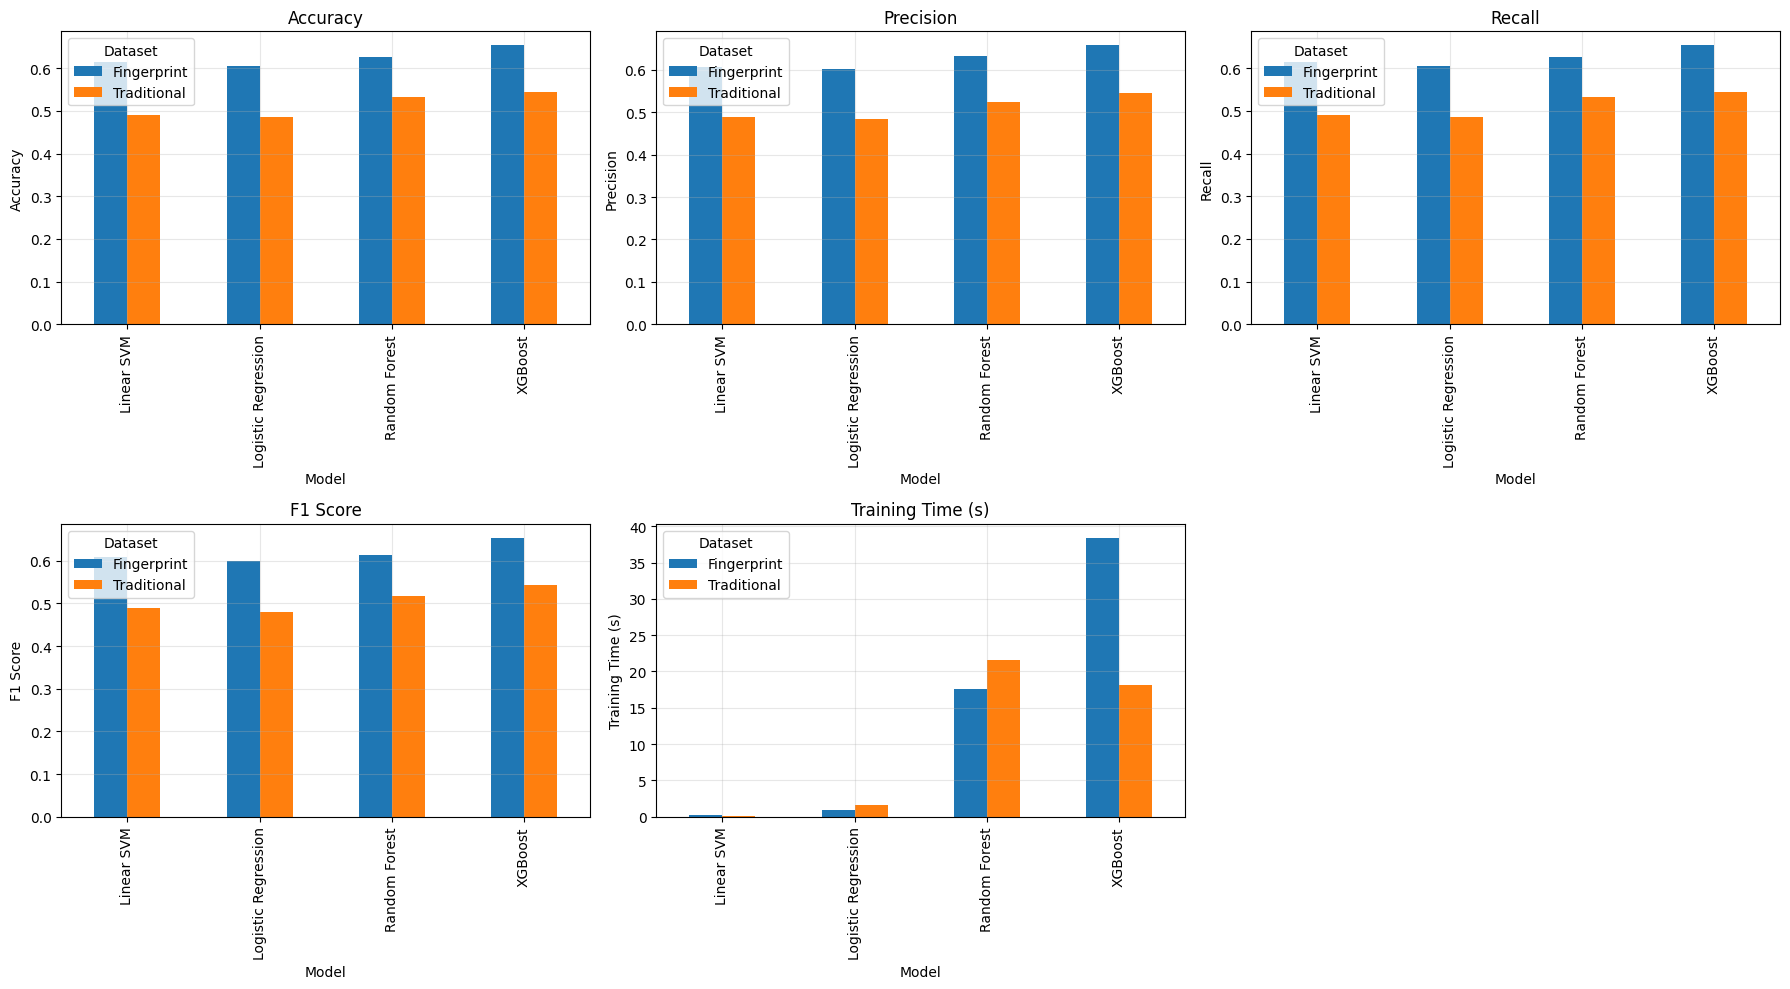

In [44]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "Training Time (s)"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):

    pivot = results_df.pivot(
        index="Model",
        columns="Dataset",
        values=metric
    )

    pivot.plot(
        kind="bar",
        ax=axes[i]
    )

    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].grid(alpha=0.3)

axes[-1].axis("off")

plt.tight_layout()

plt.savefig(
    "results/tfidf/TFIDF_Performance_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
import os

os.makedirs("results", exist_ok=True)
os.makedirs("results/tfidf", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("models/tfidf", exist_ok=True)

In [45]:
import joblib
import numpy as np
import matplotlib.pyplot as plt

# Load Random Forest model
rf = joblib.load("models/tfidf/Fingerprint_Random Forest.pkl")

# TF-IDF feature names
feature_names = fingerprint_vectorizer.get_feature_names_out()

# Top 20 important features
importance = rf.feature_importances_
idx = np.argsort(importance)[::-1][:20]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy Gain
comparison["Difference"].plot(
    kind="bar",
    ax=axes[0],
    color="steelblue"
)

axes[0].set_title("Accuracy Gain (Fingerprint vs Traditional)")
axes[0].set_ylabel("Accuracy Difference")
axes[0].grid(alpha=0.3)

# Random Forest Feature Importance
axes[1].barh(
    feature_names[idx][::-1],
    importance[idx][::-1]
)

axes[1].set_title("Top 20 TF-IDF Features (Random Forest)")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("results/tfidf/TFIDF_Analysis.png", dpi=300)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'models/tfidf/Fingerprint_Random Forest.pkl'

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

fingerprint_vectorizer = TfidfVectorizer(
    max_features=10000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)
)

fingerprint_vectorizer.fit(fingerprint_df["generated_text"])

TfidfVectorizer(max_df=0.95, max_features=10000, min_df=2, ngram_range=(1, 2))

In [41]:
import os

for root, dirs, files in os.walk("models"):
    for file in files:
        print(os.path.join(root, file))

In [47]:
# ==========================================================
# CHARACTER N-GRAM FEATURE EVALUATION
# PART 1
# ==========================================================

import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ----------------------------------------------------------
# Create Output Folders
# ----------------------------------------------------------

os.makedirs("results", exist_ok=True)
os.makedirs("results/character_ngram", exist_ok=True)

os.makedirs("models", exist_ok=True)
os.makedirs("models/character_ngram", exist_ok=True)

# ----------------------------------------------------------
# Character N-Gram Train / Validation / Test
# ----------------------------------------------------------

X_fp_train = X_fingerprint_char[fp_train_idx]
X_fp_valid = X_fingerprint_char[fp_valid_idx]
X_fp_test  = X_fingerprint_char[fp_test_idx]

y_fp_train = y_fingerprint.iloc[fp_train_idx]
y_fp_valid = y_fingerprint.iloc[fp_valid_idx]
y_fp_test  = y_fingerprint.iloc[fp_test_idx]

X_tr_train = X_traditional_char[tr_train_idx]
X_tr_valid = X_traditional_char[tr_valid_idx]
X_tr_test  = X_traditional_char[tr_test_idx]

y_tr_train = y_traditional.iloc[tr_train_idx]
y_tr_valid = y_traditional.iloc[tr_valid_idx]
y_tr_test  = y_traditional.iloc[tr_test_idx]

print("="*70)
print("Character N-Gram Dataset Ready")
print("="*70)

print("Fingerprint Train :", X_fp_train.shape)
print("Fingerprint Test  :", X_fp_test.shape)

print()

print("Traditional Train :", X_tr_train.shape)
print("Traditional Test  :", X_tr_test.shape)

# ----------------------------------------------------------
# Label Encoder (Only for XGBoost)
# ----------------------------------------------------------

label_encoder = LabelEncoder()

label_encoder.fit(y_fingerprint)

y_fp_train_enc = label_encoder.transform(y_fp_train)
y_fp_test_enc  = label_encoder.transform(y_fp_test)

y_tr_train_enc = label_encoder.transform(y_tr_train)
y_tr_test_enc  = label_encoder.transform(y_tr_test)

# ----------------------------------------------------------
# Models
# ----------------------------------------------------------

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "Linear SVM":
        LinearSVC(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(

            n_estimators=300,

            random_state=42,

            n_jobs=-1

        ),

    "XGBoost":
XGBClassifier(

    n_estimators=100,

    max_depth=4,

    learning_rate=0.1,

    subsample=0.8,

    colsample_bytree=0.8,

    tree_method="hist",

    eval_metric="mlogloss",

    random_state=42,

    n_jobs=-1

)

}

results = []

# ----------------------------------------------------------
# Evaluation Function
# ----------------------------------------------------------

def run_experiment(
        dataset_name,
        model_name,
        model,
        X_train,
        y_train,
        X_test,
        y_test):

    print("\n")
    print("="*80)
    print(dataset_name,"|",model_name)
    print("="*80)

    start = time.time()

    # ----------------------------------------
    # XGBoost uses encoded labels
    # ----------------------------------------

    if model_name == "XGBoost":

        if dataset_name == "Fingerprint":

            model.fit(
                X_train,
                y_fp_train_enc
            )

            pred = model.predict(X_test)

            true = y_fp_test_enc

            pred = label_encoder.inverse_transform(pred)

            true = label_encoder.inverse_transform(true)

        else:

            model.fit(
                X_train,
                y_tr_train_enc
            )

            pred = model.predict(X_test)

            true = y_tr_test_enc

            pred = label_encoder.inverse_transform(pred)

            true = label_encoder.inverse_transform(true)

    else:

        model.fit(
            X_train,
            y_train
        )

        pred = model.predict(X_test)

        true = y_test

    train_time = time.time()-start

    start = time.time()

    prediction_time = time.time()-start

    accuracy = accuracy_score(true,pred)

    precision,recall,f1,_ = precision_recall_fscore_support(

        true,

        pred,

        average="weighted"

    )

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nClassification Report\n")

    print(

        classification_report(

            true,

            pred

        )

    )
        # ----------------------------------------------------------
    # Confusion Matrix
    # ----------------------------------------------------------

    cm = confusion_matrix(true, pred)

    fig, ax = plt.subplots(figsize=(6,6))

    ConfusionMatrixDisplay(
        confusion_matrix=cm
    ).plot(
        ax=ax,
        xticks_rotation=45,
        cmap="Blues"
    )

    plt.title(f"{dataset_name} - {model_name}")

    plt.tight_layout()

    plt.savefig(

        f"results/character_ngram/{dataset_name}_{model_name}_CM.png",

        dpi=300

    )

    plt.close()

    # ----------------------------------------------------------
    # Save Model
    # ----------------------------------------------------------

    joblib.dump(

        model,

        f"models/character_ngram/{dataset_name}_{model_name}.pkl"

    )

    # ----------------------------------------------------------
    # Store Results
    # ----------------------------------------------------------

    results.append({

        "Dataset":dataset_name,

        "Model":model_name,

        "Accuracy":accuracy,

        "Precision":precision,

        "Recall":recall,

        "F1 Score":f1,

        "Training Time (s)":train_time,

        "Prediction Time (s)":prediction_time

    })

# ==========================================================
# Fingerprint Experiments
# ==========================================================

print("\n")
print("="*80)
print("Fingerprint")
print("="*80)

for name, model in models.items():

    print(f"\nTraining {name}...")

    run_experiment(

        "Fingerprint",

        name,

        model,

        X_fp_train,

        y_fp_train,

        X_fp_test,

        y_fp_test

    )

# ==========================================================
# Traditional Experiments
# ==========================================================

print("\n")
print("="*80)
print("Traditional")
print("="*80)

for name, model in models.items():

    print(f"\nTraining {name}...")

    run_experiment(

        "Traditional",

        name,

        model,

        X_tr_train,

        y_tr_train,

        X_tr_test,

        y_tr_test

    )

# ==========================================================
# Final Results
# ==========================================================

results_df = pd.DataFrame(results)

print("\n")
print("="*100)
print("FINAL RESULTS")
print("="*100)

display(results_df)

results_df.to_csv(

    "results/character_ngram/character_ngram_results.csv",

    index=False

)

# ==========================================================
# Accuracy Comparison
# ==========================================================

comparison = results_df.pivot(

    index="Model",

    columns="Dataset",

    values="Accuracy"

)

comparison["Difference"] = (

    comparison["Fingerprint"]

    -

    comparison["Traditional"]

)

print("\nAccuracy Comparison")

display(

    comparison.sort_values(

        by="Fingerprint",

        ascending=False

    )

)

Character N-Gram Dataset Ready
Fingerprint Train : (3666, 15000)
Fingerprint Test  : (786, 15000)

Traditional Train : (3666, 15000)
Traditional Test  : (786, 15000)


Fingerprint

Training Logistic Regression...


Fingerprint | Logistic Regression
Accuracy  : 0.6565
Precision : 0.6538
Recall    : 0.6565
F1 Score  : 0.6519

Classification Report

              precision    recall  f1-score   support

      gemma2       0.69      0.59      0.64       150
      llama3       0.54      0.49      0.52       148
     mistral       0.74      0.77      0.76       150
        phi3       0.63      0.56      0.59       150
   qwen_tiny       0.66      0.82      0.73       188

    accuracy                           0.66       786
   macro avg       0.65      0.65      0.65       786
weighted avg       0.65      0.66      0.65       786


Training Linear SVM...


Fingerprint | Linear SVM
Accuracy  : 0.6845
Precision : 0.6816
Recall    : 0.6845
F1 Score  : 0.6802

Classification Report

           

,Dataset,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s),Prediction Time (s)
0,Fingerprint,Logistic Regression,0.656489,0.653791,0.656489,0.651879,9.019511,2.384186e-07
1,Fingerprint,Linear SVM,0.684478,0.681602,0.684478,0.680170,1.472348,4.768372e-07
2,Fingerprint,Random Forest,0.648855,0.672104,0.648855,0.642277,34.964949,2.384186e-07
3,Fingerprint,XGBoost,0.642494,0.665625,0.642494,0.644683,283.403037,4.768372e-07
4,Traditional,Logistic Regression,0.554707,0.551809,0.554707,0.549388,4.495648,4.768372e-07
5,Traditional,Linear SVM,0.552163,0.548596,0.552163,0.549817,0.641088,7.152557e-07
6,Traditional,Random Forest,0.545802,0.534896,0.545802,0.531342,30.496038,2.384186e-07
7,Traditional,XGBoost,0.562341,0.565194,0.562341,0.557509,182.042113,2.384186e-07



Accuracy Comparison


Dataset,Fingerprint,Traditional,Difference
Model,,,
Linear SVM,0.684478,0.552163,0.132316
Logistic Regression,0.656489,0.554707,0.101781
Random Forest,0.648855,0.545802,0.103053
XGBoost,0.642494,0.562341,0.080153


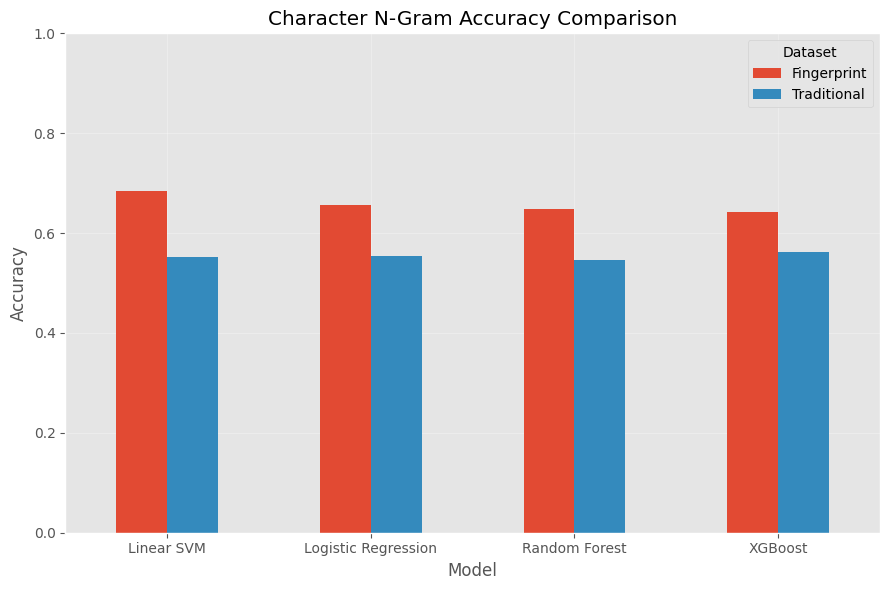

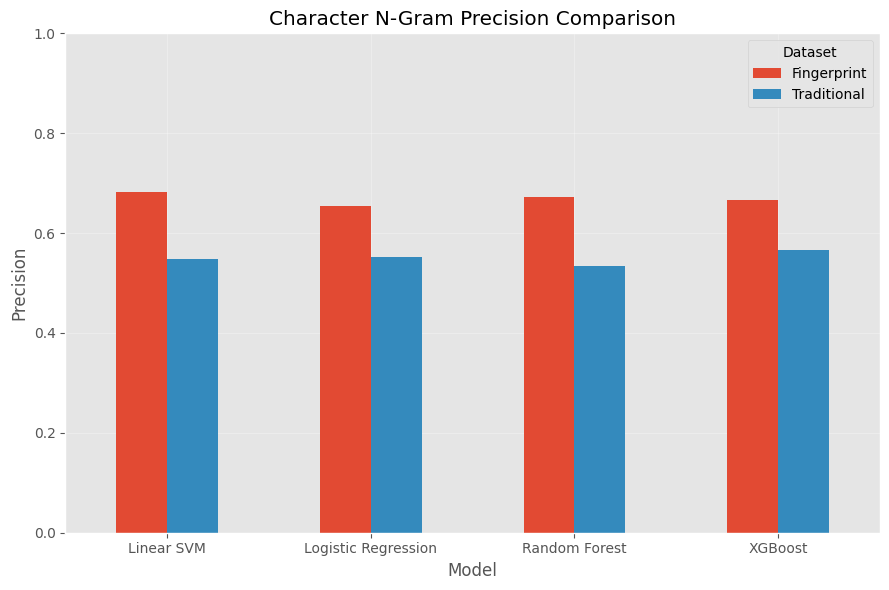

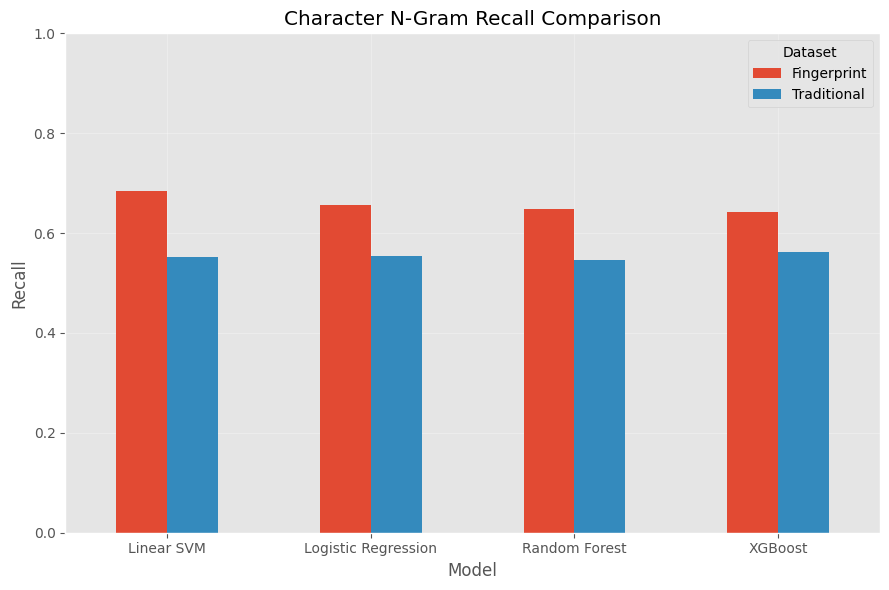

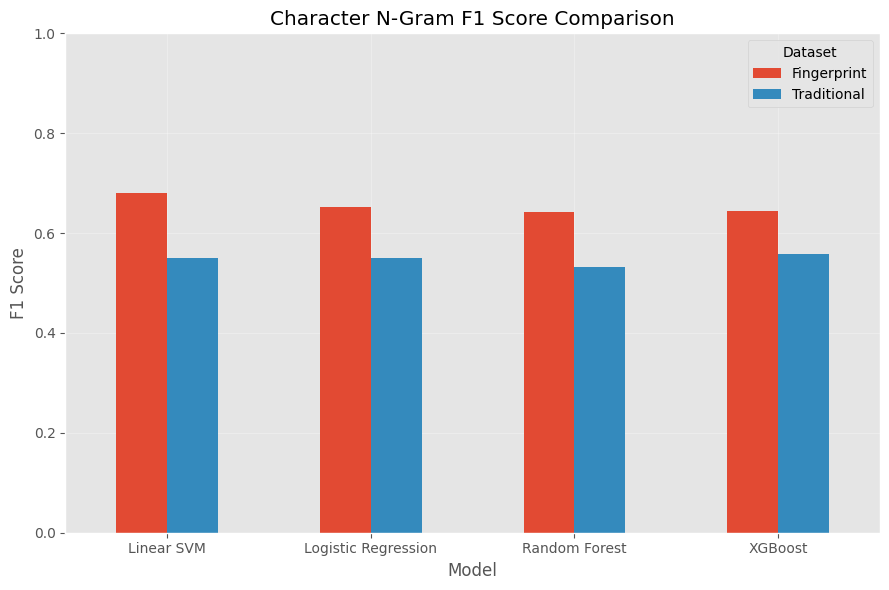

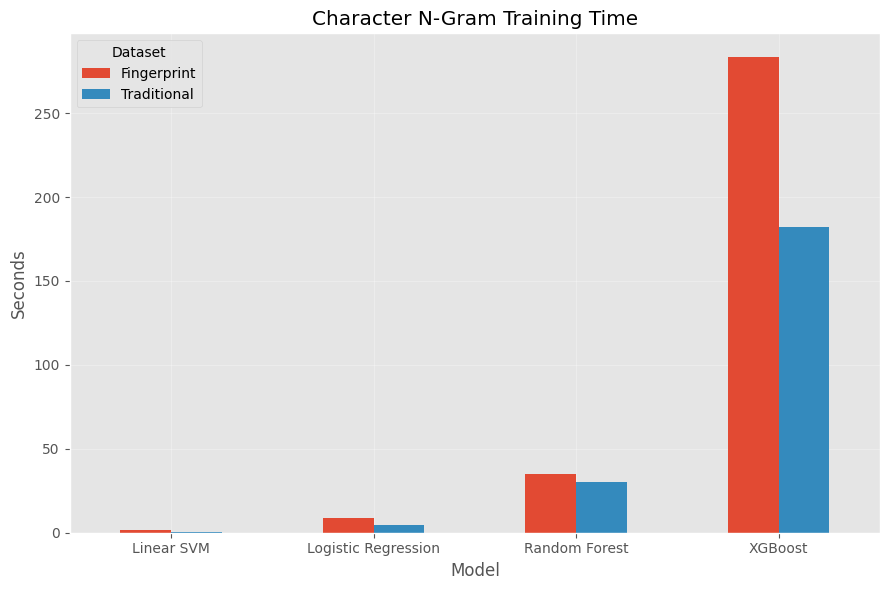

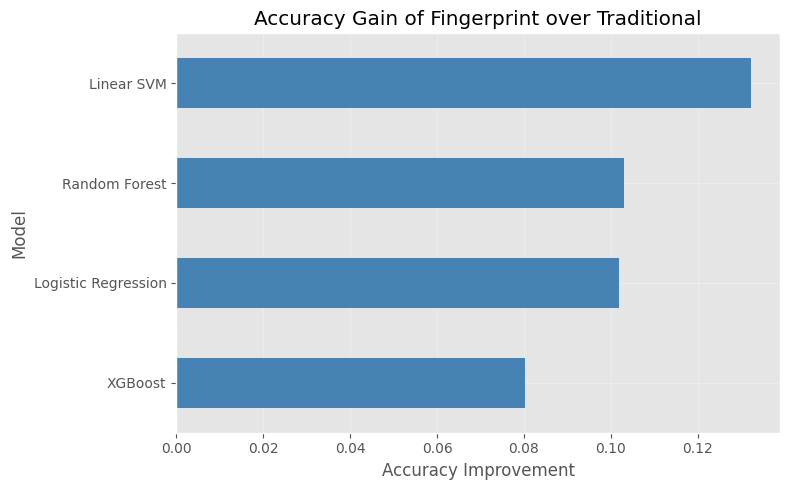

Publication Figures Generated Successfully

Saved Figures
---------------------------
Accuracy_Comparison.png
Precision_Comparison.png
Recall_Comparison.png
F1_Comparison.png
Training_Time.png
Accuracy_Gain.png


In [48]:
# ==========================================================
# CHARACTER N-GRAM
# PART 3
# Publication Quality Figures
# ==========================================================

import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("results/character_ngram", exist_ok=True)

plt.style.use("ggplot")

# ==========================================================
# Figure 1
# Accuracy Comparison
# ==========================================================

comparison = results_df.pivot(
    index="Model",
    columns="Dataset",
    values="Accuracy"
)

comparison.plot(
    kind="bar",
    figsize=(9,6),
    rot=0
)

plt.title("Character N-Gram Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(
    "results/character_ngram/Accuracy_Comparison.png",
    dpi=300
)

plt.show()

# ==========================================================
# Figure 2
# Precision Comparison
# ==========================================================

comparison = results_df.pivot(
    index="Model",
    columns="Dataset",
    values="Precision"
)

comparison.plot(
    kind="bar",
    figsize=(9,6),
    rot=0
)

plt.title("Character N-Gram Precision Comparison")
plt.ylabel("Precision")
plt.ylim(0,1)
plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(
    "results/character_ngram/Precision_Comparison.png",
    dpi=300
)

plt.show()

# ==========================================================
# Figure 3
# Recall Comparison
# ==========================================================

comparison = results_df.pivot(
    index="Model",
    columns="Dataset",
    values="Recall"
)

comparison.plot(
    kind="bar",
    figsize=(9,6),
    rot=0
)

plt.title("Character N-Gram Recall Comparison")
plt.ylabel("Recall")
plt.ylim(0,1)
plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(
    "results/character_ngram/Recall_Comparison.png",
    dpi=300
)

plt.show()

# ==========================================================
# Figure 4
# F1 Comparison
# ==========================================================

comparison = results_df.pivot(
    index="Model",
    columns="Dataset",
    values="F1 Score"
)

comparison.plot(
    kind="bar",
    figsize=(9,6),
    rot=0
)

plt.title("Character N-Gram F1 Score Comparison")
plt.ylabel("F1 Score")
plt.ylim(0,1)
plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(
    "results/character_ngram/F1_Comparison.png",
    dpi=300
)

plt.show()

# ==========================================================
# Figure 5
# Training Time
# ==========================================================

comparison = results_df.pivot(
    index="Model",
    columns="Dataset",
    values="Training Time (s)"
)

comparison.plot(
    kind="bar",
    figsize=(9,6),
    rot=0
)

plt.title("Character N-Gram Training Time")
plt.ylabel("Seconds")
plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(
    "results/character_ngram/Training_Time.png",
    dpi=300
)

plt.show()

# ==========================================================
# Figure 6
# Accuracy Gain
# ==========================================================

gain = (
    results_df
    .pivot(index="Model",
           columns="Dataset",
           values="Accuracy")
)

gain["Gain"] = (
    gain["Fingerprint"]
    -
    gain["Traditional"]
)

gain["Gain"].sort_values().plot(

    kind="barh",

    figsize=(8,5),

    color="steelblue"

)

plt.title("Accuracy Gain of Fingerprint over Traditional")
plt.xlabel("Accuracy Improvement")

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(
    "results/character_ngram/Accuracy_Gain.png",
    dpi=300
)

plt.show()

print("="*80)
print("Publication Figures Generated Successfully")
print("="*80)

print()

print("Saved Figures")

print("---------------------------")

print("Accuracy_Comparison.png")
print("Precision_Comparison.png")
print("Recall_Comparison.png")
print("F1_Comparison.png")
print("Training_Time.png")
print("Accuracy_Gain.png")

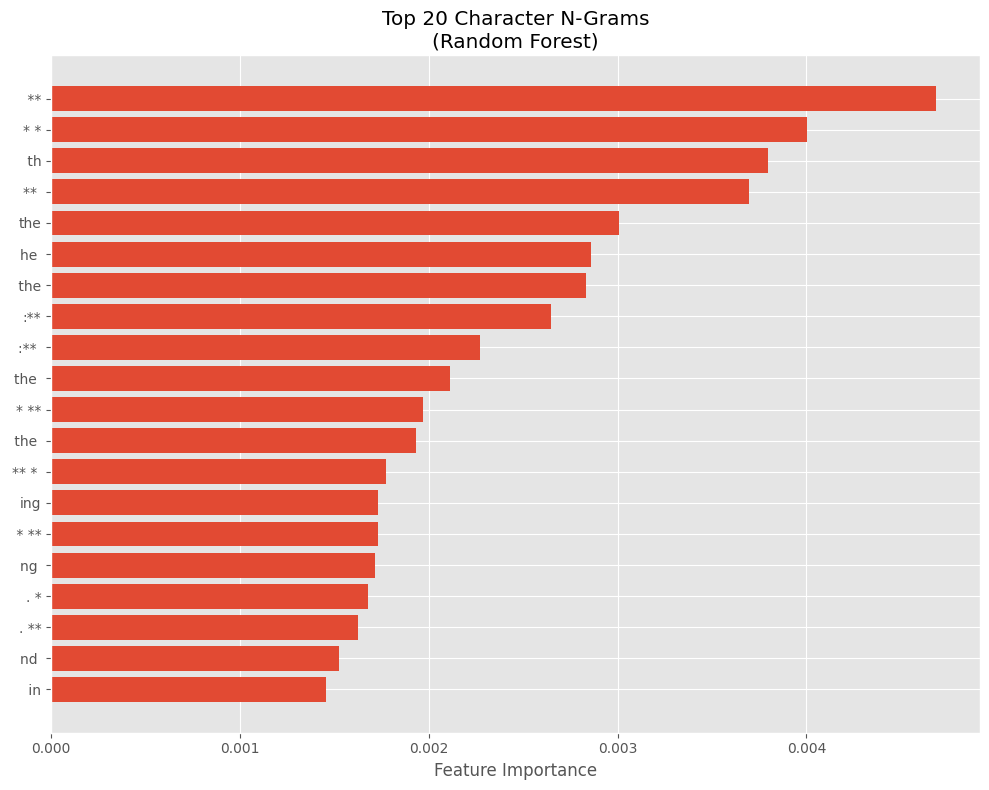

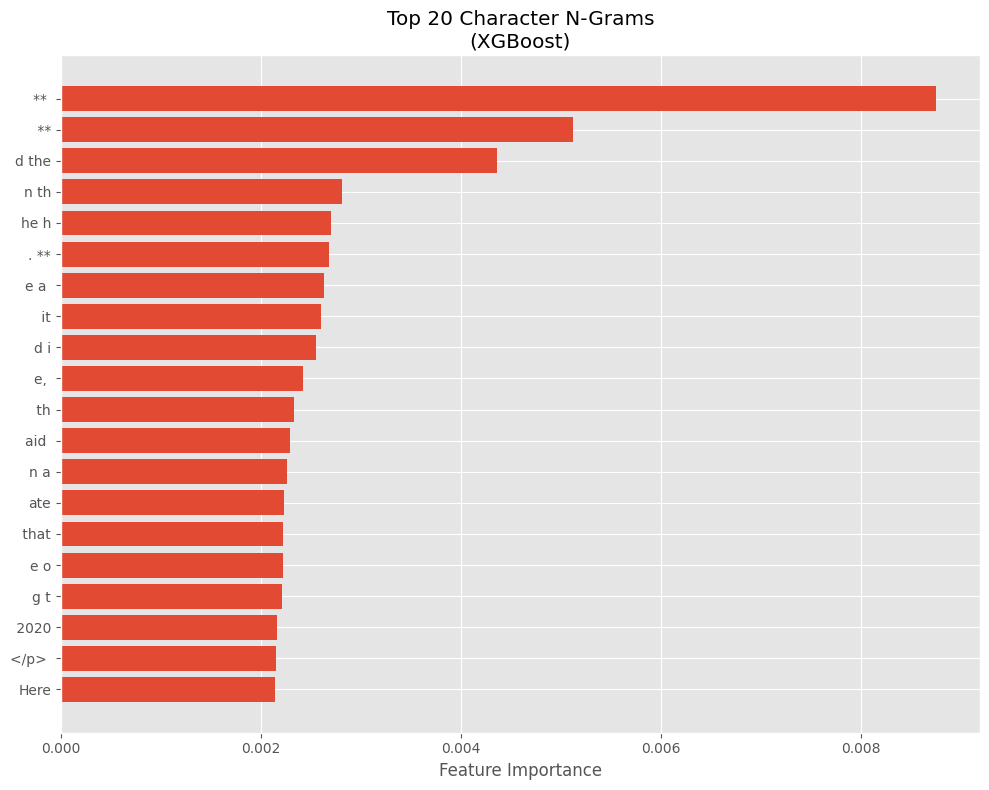

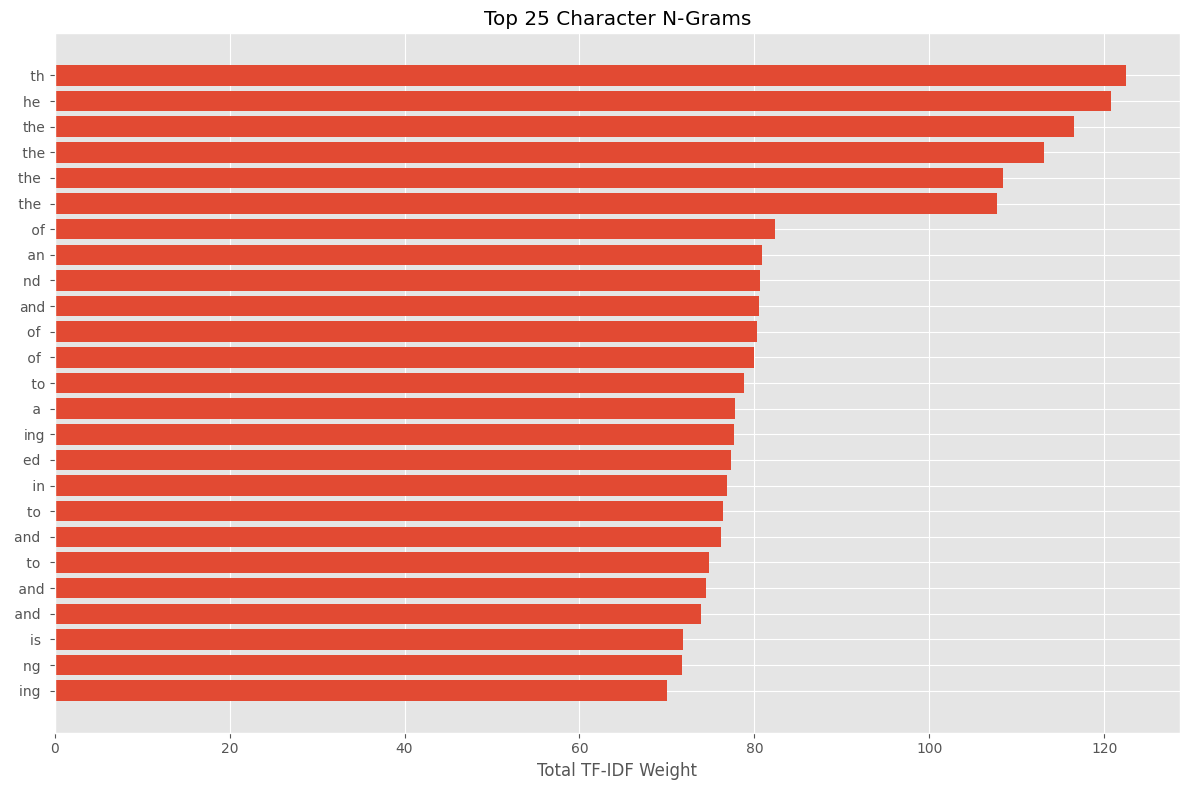

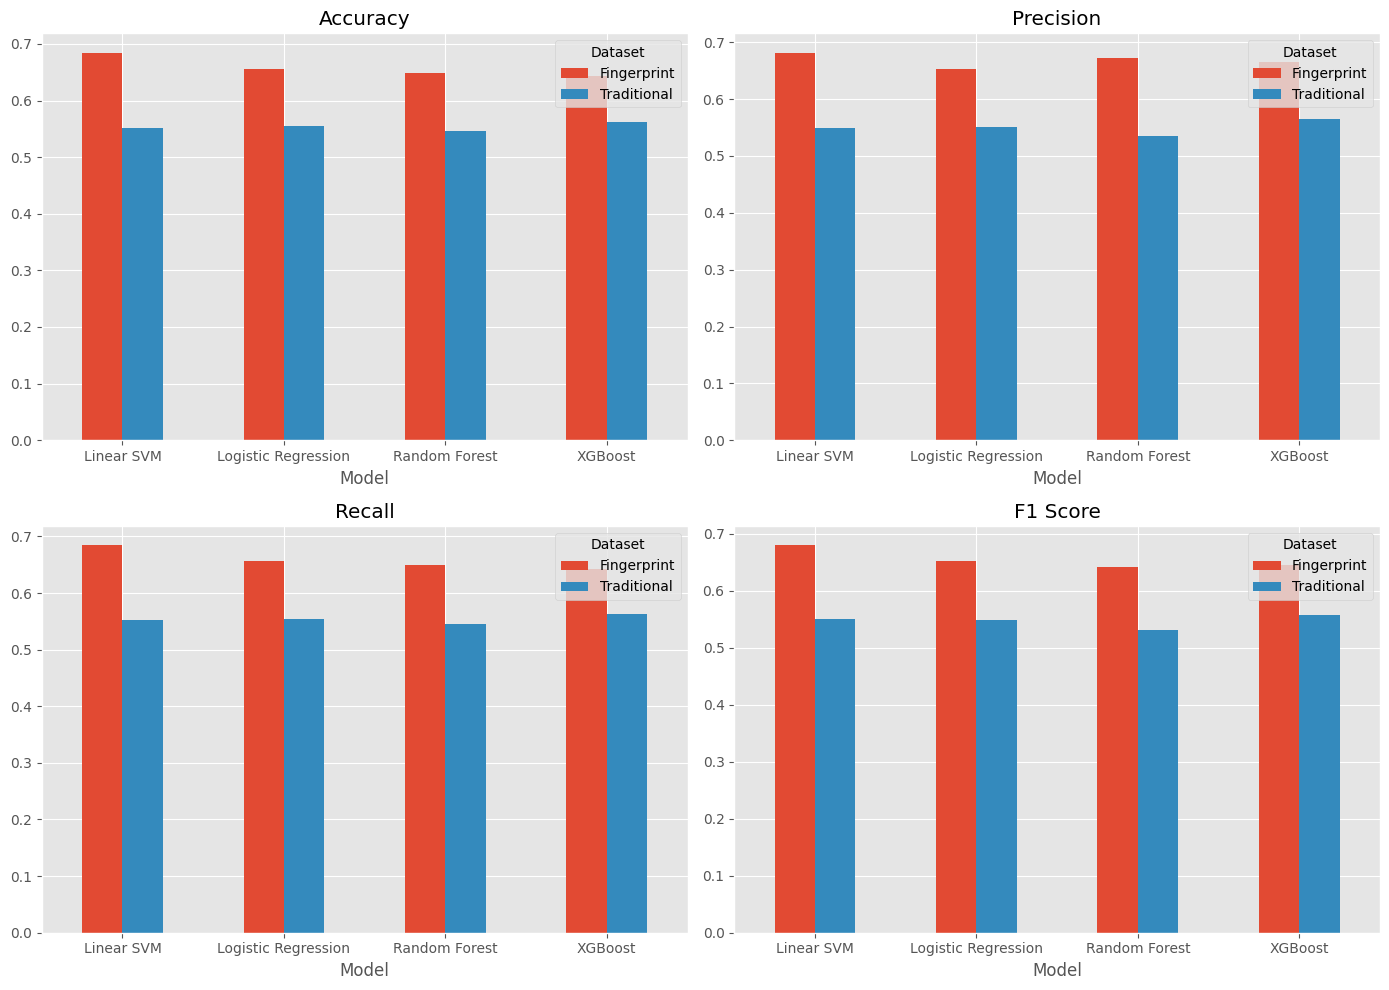

CHARACTER N-GRAM FEATURE FAMILY

Best Model : Linear SVM
Dataset    : Fingerprint
Accuracy   : 68.45 %

Accuracy Gain


Dataset,Fingerprint,Traditional,Gain
Model,,,
Linear SVM,0.684478,0.552163,0.132316
Logistic Regression,0.656489,0.554707,0.101781
Random Forest,0.648855,0.545802,0.103053
XGBoost,0.642494,0.562341,0.080153



Overall Observation
Fingerprint-preserving preprocessing consistently outperformed Traditional NLP across Character N-Gram features.

All figures saved to results/character_ngram/


In [49]:
# ==========================================================
# CHARACTER N-GRAM
# PART 4
# Feature Importance & Publication Figures
# ==========================================================

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

# ----------------------------------------------------------
# Load Models
# ----------------------------------------------------------

rf = joblib.load(
    "models/character_ngram/Fingerprint_Random Forest.pkl"
)

try:
    xgb = joblib.load(
        "models/character_ngram/Fingerprint_XGBoost.pkl"
    )
    HAS_XGB = True
except:
    HAS_XGB = False

# ----------------------------------------------------------
# Character N-Gram Names
# ----------------------------------------------------------

feature_names = char_vectorizer.get_feature_names_out()

# ==========================================================
# Figure 1
# Random Forest Feature Importance
# ==========================================================

importance = rf.feature_importances_

idx = np.argsort(importance)[::-1][:20]

plt.figure(figsize=(10,8))

plt.barh(
    feature_names[idx][::-1],
    importance[idx][::-1]
)

plt.title("Top 20 Character N-Grams\n(Random Forest)")
plt.xlabel("Feature Importance")

plt.tight_layout()

plt.savefig(
    "results/character_ngram/RF_Feature_Importance.png",
    dpi=300
)

plt.show()

# ==========================================================
# Figure 2
# XGBoost Feature Importance
# ==========================================================

if HAS_XGB:

    importance = xgb.feature_importances_

    idx = np.argsort(importance)[::-1][:20]

    plt.figure(figsize=(10,8))

    plt.barh(
        feature_names[idx][::-1],
        importance[idx][::-1]
    )

    plt.title("Top 20 Character N-Grams\n(XGBoost)")
    plt.xlabel("Feature Importance")

    plt.tight_layout()

    plt.savefig(
        "results/character_ngram/XGB_Feature_Importance.png",
        dpi=300
    )

    plt.show()

else:

    print("XGBoost model not available.")

# ==========================================================
# Figure 3
# Top Character N-Grams
# ==========================================================

scores = np.asarray(

    X_fingerprint_char.sum(axis=0)

).ravel()

idx = scores.argsort()[::-1][:25]

plt.figure(figsize=(12,8))

plt.barh(
    feature_names[idx][::-1],
    scores[idx][::-1]
)

plt.title("Top 25 Character N-Grams")
plt.xlabel("Total TF-IDF Weight")

plt.tight_layout()

plt.savefig(
    "results/character_ngram/Top_Character_NGrams.png",
    dpi=300
)

plt.show()

# ==========================================================
# Figure 4
# Combined Performance Dashboard
# ==========================================================

comparison = results_df.pivot(
    index="Model",
    columns="Dataset",
    values="Accuracy"
)

precision = results_df.pivot(
    index="Model",
    columns="Dataset",
    values="Precision"
)

recall = results_df.pivot(
    index="Model",
    columns="Dataset",
    values="Recall"
)

f1 = results_df.pivot(
    index="Model",
    columns="Dataset",
    values="F1 Score"
)

fig,ax = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

comparison.plot(kind="bar",ax=ax[0,0],rot=0)
ax[0,0].set_title("Accuracy")

precision.plot(kind="bar",ax=ax[0,1],rot=0)
ax[0,1].set_title("Precision")

recall.plot(kind="bar",ax=ax[1,0],rot=0)
ax[1,0].set_title("Recall")

f1.plot(kind="bar",ax=ax[1,1],rot=0)
ax[1,1].set_title("F1 Score")

plt.tight_layout()

plt.savefig(
    "results/character_ngram/Performance_Dashboard.png",
    dpi=300
)

plt.show()

# ==========================================================
# Research Summary
# ==========================================================

print("="*90)
print("CHARACTER N-GRAM FEATURE FAMILY")
print("="*90)

best = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print()

print("Best Model :",best["Model"])
print("Dataset    :",best["Dataset"])
print("Accuracy   :",round(best["Accuracy"]*100,2),"%")

print()

gain = (
    results_df
    .pivot(
        index="Model",
        columns="Dataset",
        values="Accuracy"
    )
)

gain["Gain"] = gain["Fingerprint"]-gain["Traditional"]

print("Accuracy Gain")

display(gain)

print()

print("Overall Observation")

if gain["Gain"].mean()>0:

    print(
        "Fingerprint-preserving preprocessing consistently "
        "outperformed Traditional NLP across Character N-Gram features."
    )

else:

    print(
        "Traditional preprocessing achieved comparable performance."
    )

print()

print("All figures saved to results/character_ngram/")

In [50]:
# ==========================================================
# FEATURE FAMILY 3
# STYLOMETRIC FEATURE EXTRACTION
# PART 1
# ==========================================================

import re
import string
import numpy as np
import pandas as pd

from collections import Counter
from sklearn.preprocessing import StandardScaler

print("="*80)
print("Stylometric Feature Extraction")
print("="*80)

# ----------------------------------------------------------
# Helper Function
# ----------------------------------------------------------

def extract_stylometric_features(text):

    if pd.isna(text):
        text = ""

    words = re.findall(r"\b\w+\b", text.lower())
    sentences = re.split(r"[.!?]+", text)

    characters = len(text)

    word_count = len(words)

    sentence_count = max(1, len([s for s in sentences if s.strip()]))

    unique_words = len(set(words))

    avg_word_length = (
        np.mean([len(w) for w in words])
        if word_count > 0 else 0
    )

    avg_sentence_length = (
        word_count / sentence_count
    )

    # -----------------------
    # Lexical Richness
    # -----------------------

    ttr = (
        unique_words / word_count
        if word_count else 0
    )

    hapax = (
        len([w for w,c in Counter(words).items() if c==1])
        / word_count
        if word_count else 0
    )

    # -----------------------
    # Character Ratios
    # -----------------------

    uppercase_ratio = (
        sum(c.isupper() for c in text)
        / max(characters,1)
    )

    digit_ratio = (
        sum(c.isdigit() for c in text)
        / max(characters,1)
    )

    whitespace_ratio = (
        sum(c.isspace() for c in text)
        / max(characters,1)
    )

    punctuation_ratio = (
        sum(c in string.punctuation for c in text)
        / max(characters,1)
    )

    # -----------------------
    # Punctuation Counts
    # -----------------------

    comma = text.count(",")

    period = text.count(".")

    semicolon = text.count(";")

    colon = text.count(":")

    question = text.count("?")

    exclamation = text.count("!")

    quotes = text.count('"')

    dash = text.count("-")

    parenthesis = (
        text.count("(")
        +
        text.count(")")
    )

    # -----------------------
    # Readability Proxies
    # -----------------------

    long_words = sum(
        len(w)>=7
        for w in words
    )

    short_words = sum(
        len(w)<=3
        for w in words
    )

    lexical_density = (
        long_words / word_count
        if word_count else 0
    )

    short_word_ratio = (
        short_words / word_count
        if word_count else 0
    )

    return [

        characters,

        word_count,

        sentence_count,

        unique_words,

        avg_word_length,

        avg_sentence_length,

        ttr,

        hapax,

        uppercase_ratio,

        digit_ratio,

        whitespace_ratio,

        punctuation_ratio,

        comma,

        period,

        semicolon,

        colon,

        question,

        exclamation,

        quotes,

        dash,

        parenthesis,

        lexical_density,

        short_word_ratio

    ]

# ----------------------------------------------------------
# Feature Names
# ----------------------------------------------------------

feature_names = [

    "char_count",

    "word_count",

    "sentence_count",

    "unique_words",

    "avg_word_length",

    "avg_sentence_length",

    "type_token_ratio",

    "hapax_ratio",

    "uppercase_ratio",

    "digit_ratio",

    "whitespace_ratio",

    "punctuation_ratio",

    "comma",

    "period",

    "semicolon",

    "colon",

    "question",

    "exclamation",

    "quotes",

    "dash",

    "parenthesis",

    "lexical_density",

    "short_word_ratio"

]

# ----------------------------------------------------------
# Fingerprint Dataset
# ----------------------------------------------------------

X_fingerprint_style = np.array(

    fingerprint_df["generated_text"].apply(
        extract_stylometric_features
    ).tolist()

)

# ----------------------------------------------------------
# Traditional Dataset
# ----------------------------------------------------------

X_traditional_style = np.array(

    traditional_df["generated_text"].apply(
        extract_stylometric_features
    ).tolist()

)

# ----------------------------------------------------------
# Feature Scaling
# ----------------------------------------------------------

scaler = StandardScaler()

X_fingerprint_style = scaler.fit_transform(
    X_fingerprint_style
)

X_traditional_style = scaler.transform(
    X_traditional_style
)

print()

print("Fingerprint Shape :", X_fingerprint_style.shape)

print("Traditional Shape :", X_traditional_style.shape)

print()

print("Number of Stylometric Features :",
      X_fingerprint_style.shape[1])

print()

style_df = pd.DataFrame(
    X_fingerprint_style,
    columns=feature_names
)

display(style_df.head())

print()

print("Stylometric Feature Extraction Completed Successfully")

Stylometric Feature Extraction

Fingerprint Shape : (5238, 23)
Traditional Shape : (5238, 23)

Number of Stylometric Features : 23



,char_count,word_count,sentence_count,unique_words,avg_word_length,avg_sentence_length,type_token_ratio,hapax_ratio,uppercase_ratio,digit_ratio,whitespace_ratio,punctuation_ratio,comma,period,semicolon,colon,question,exclamation,quotes,dash,parenthesis,lexical_density,short_word_ratio
0,0.827809,1.184095,5.233377,0.546601,-0.715554,-1.327199,-1.059892,-1.079529,-0.526778,-0.296205,-0.645867,1.130485,-0.705509,4.583600,-0.126241,3.089406,1.629857,3.498422,1.108602,-0.344066,-0.308018,-1.137211,0.698298
1,1.008592,1.487574,1.631113,0.476800,-0.803490,-0.470773,-1.404622,-1.096287,-0.560706,-0.296205,0.666919,0.299026,-0.046254,0.464871,-0.126241,-0.456818,3.567926,3.498422,-0.457222,-0.344066,-0.308018,-1.400161,0.678741
2,-0.625416,-0.295368,-0.370145,-1.338025,-0.682205,-0.084245,-1.963468,-2.035191,-0.809880,-0.296205,0.751623,-0.514270,-1.035137,-0.358875,-0.126241,-0.456818,-0.308211,-0.143942,-0.457222,-0.344066,-0.308018,-0.965214,0.441604
3,1.467506,1.525509,2.831868,-0.011807,-0.204535,-0.857302,-1.909745,-2.238783,-0.380710,-0.296205,0.650480,-0.532017,-0.705509,0.464871,-0.126241,-0.456818,-0.308211,21.710245,-0.457222,0.632746,-0.308018,-0.208456,0.159725
4,-0.938312,-0.598848,-0.370145,-0.151409,-0.887189,-0.357088,0.913528,0.919413,0.817485,-0.209177,0.665693,0.051949,-0.705509,-0.358875,-0.126241,-0.456818,-0.308211,-0.143942,-0.457222,0.144340,-0.308018,-0.580984,1.238383



Stylometric Feature Extraction Completed Successfully


In [51]:
# ==========================================================
# STYLOMETRIC FEATURES
# PART 2
# Four Model Evaluation
# ==========================================================

import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

os.makedirs("results/stylometric",exist_ok=True)
os.makedirs("models/stylometric",exist_ok=True)

# ==========================================================
# Train/Test Split
# ==========================================================

X_fp_train = X_fingerprint_style[fp_train_idx]
X_fp_test  = X_fingerprint_style[fp_test_idx]

X_tr_train = X_traditional_style[tr_train_idx]
X_tr_test  = X_traditional_style[tr_test_idx]

y_fp_train = y_fingerprint.iloc[fp_train_idx]
y_fp_test  = y_fingerprint.iloc[fp_test_idx]

y_tr_train = y_traditional.iloc[tr_train_idx]
y_tr_test  = y_traditional.iloc[tr_test_idx]

# ==========================================================
# Label Encoding
# ==========================================================

encoder = LabelEncoder()

encoder.fit(y_fingerprint)

y_fp_train_enc = encoder.transform(y_fp_train)
y_fp_test_enc  = encoder.transform(y_fp_test)

y_tr_train_enc = encoder.transform(y_tr_train)
y_tr_test_enc  = encoder.transform(y_tr_test)

# ==========================================================
# Models
# ==========================================================

models={

"Logistic Regression":

LogisticRegression(

max_iter=1000,

random_state=42

),

"Linear SVM":

LinearSVC(

random_state=42

),

"Random Forest":

RandomForestClassifier(

n_estimators=300,

random_state=42,

n_jobs=-1

),

"XGBoost":

XGBClassifier(

n_estimators=100,

max_depth=4,

learning_rate=0.1,

subsample=0.8,

colsample_bytree=0.8,

tree_method="hist",

eval_metric="mlogloss",

random_state=42,

n_jobs=-1

)

}

results=[]

# ==========================================================
# Evaluation Function
# ==========================================================

def evaluate(

dataset,

model_name,

model,

X_train,

y_train,

X_test,

y_test

):

    print("\n")
    print("="*80)
    print(dataset,"|",model_name)
    print("="*80)

    start=time.time()

    if model_name=="XGBoost":

        if dataset=="Fingerprint":

            model.fit(X_train,y_fp_train_enc)

            pred=model.predict(X_test)

            pred=encoder.inverse_transform(pred)

            true=encoder.inverse_transform(y_fp_test_enc)

        else:

            model.fit(X_train,y_tr_train_enc)

            pred=model.predict(X_test)

            pred=encoder.inverse_transform(pred)

            true=encoder.inverse_transform(y_tr_test_enc)

    else:

        model.fit(

        X_train,

        y_train

        )

        pred=model.predict(X_test)

        true=y_test

    train_time=time.time()-start

    acc=accuracy_score(true,pred)

    prec,rec,f1,_=precision_recall_fscore_support(

        true,

        pred,

        average="weighted"

    )

    print()

    print("Accuracy :",round(acc,4))
    print("Precision:",round(prec,4))
    print("Recall   :",round(rec,4))
    print("F1 Score :",round(f1,4))

    print()

    print(classification_report(true,pred))

    cm=confusion_matrix(true,pred)

    fig,ax=plt.subplots(figsize=(6,6))

    ConfusionMatrixDisplay(cm).plot(ax=ax)

    plt.title(dataset+" - "+model_name)

    plt.tight_layout()

    plt.savefig(

        f"results/stylometric/{dataset}_{model_name}_CM.png",

        dpi=300

    )

    plt.close()

    joblib.dump(

        model,

        f"models/stylometric/{dataset}_{model_name}.pkl"

    )

    results.append({

        "Dataset":dataset,

        "Model":model_name,

        "Accuracy":acc,

        "Precision":prec,

        "Recall":rec,

        "F1 Score":f1,

        "Training Time":train_time

    })

# ==========================================================
# Fingerprint
# ==========================================================

for name,model in models.items():

    evaluate(

        "Fingerprint",

        name,

        model,

        X_fp_train,

        y_fp_train,

        X_fp_test,

        y_fp_test

    )

# ==========================================================
# Traditional
# ==========================================================

for name,model in models.items():

    evaluate(

        "Traditional",

        name,

        model,

        X_tr_train,

        y_tr_train,

        X_tr_test,

        y_tr_test

    )

# ==========================================================
# Final Results
# ==========================================================

results_df=pd.DataFrame(results)

display(results_df)

results_df.to_csv(

"results/stylometric/stylometric_results.csv",

index=False

)

comparison=results_df.pivot(

index="Model",

columns="Dataset",

values="Accuracy"

)

comparison["Difference"]=comparison["Fingerprint"]-comparison["Traditional"]

print()

print("="*80)

print("STYLOMETRIC RESULTS")

print("="*80)

display(comparison.sort_values(

by="Fingerprint",

ascending=False

))



Fingerprint | Logistic Regression

Accuracy : 0.7176
Precision: 0.7172
Recall   : 0.7176
F1 Score : 0.7173

              precision    recall  f1-score   support

      gemma2       0.63      0.62      0.63       150
      llama3       0.59      0.57      0.58       148
     mistral       0.63      0.66      0.64       150
        phi3       0.82      0.83      0.83       150
   qwen_tiny       0.88      0.87      0.87       188

    accuracy                           0.72       786
   macro avg       0.71      0.71      0.71       786
weighted avg       0.72      0.72      0.72       786



Fingerprint | Linear SVM

Accuracy : 0.6858
Precision: 0.6876
Recall   : 0.6858
F1 Score : 0.6842

              precision    recall  f1-score   support

      gemma2       0.62      0.63      0.63       150
      llama3       0.57      0.47      0.51       148
     mistral       0.57      0.69      0.62       150
        phi3       0.79      0.73      0.76       150
   qwen_tiny       0.84      

,Dataset,Model,Accuracy,Precision,Recall,F1 Score,Training Time
0,Fingerprint,Logistic Regression,0.717557,0.717204,0.717557,0.717251,0.373769
1,Fingerprint,Linear SVM,0.685751,0.687591,0.685751,0.684180,0.311229
2,Fingerprint,Random Forest,0.760814,0.763127,0.760814,0.761514,7.999693
3,Fingerprint,XGBoost,0.756997,0.760403,0.756997,0.757468,2.448660
4,Traditional,Logistic Regression,0.553435,0.557671,0.553435,0.551614,2.307102
5,Traditional,Linear SVM,0.567430,0.575104,0.567430,0.561564,0.082232
6,Traditional,Random Forest,0.609415,0.611387,0.609415,0.607991,2.340092
7,Traditional,XGBoost,0.595420,0.599969,0.595420,0.596116,0.513844



STYLOMETRIC RESULTS


Dataset,Fingerprint,Traditional,Difference
Model,,,
Random Forest,0.760814,0.609415,0.151399
XGBoost,0.756997,0.595420,0.161578
Logistic Regression,0.717557,0.553435,0.164122
Linear SVM,0.685751,0.567430,0.118321


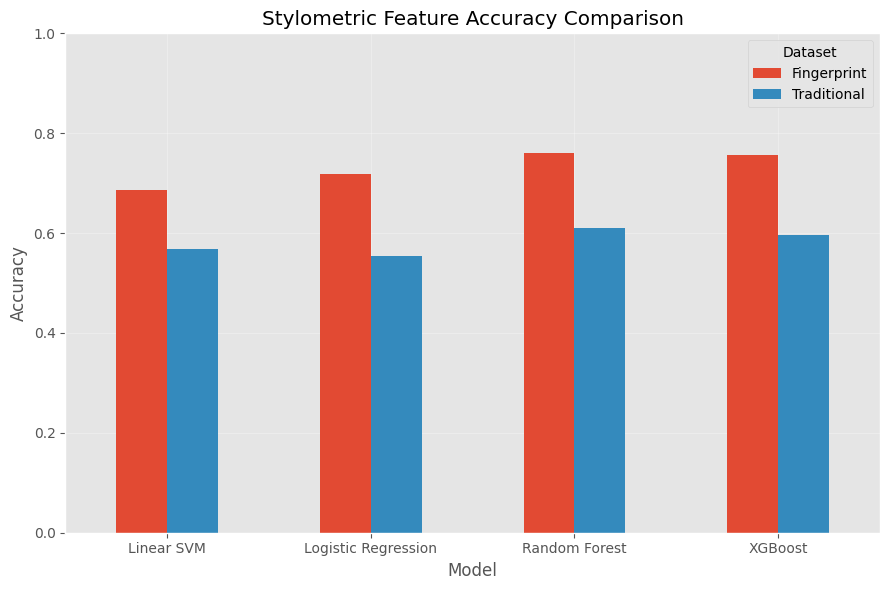

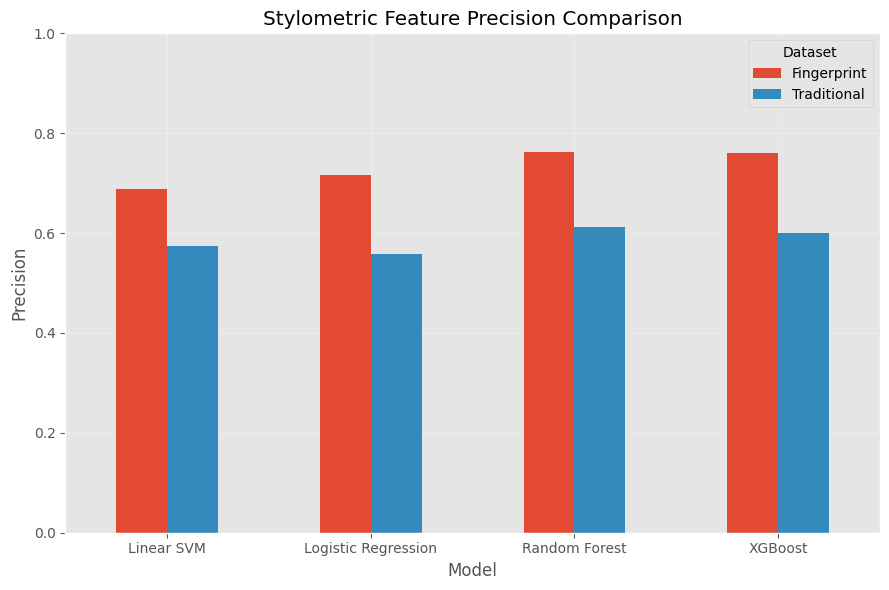

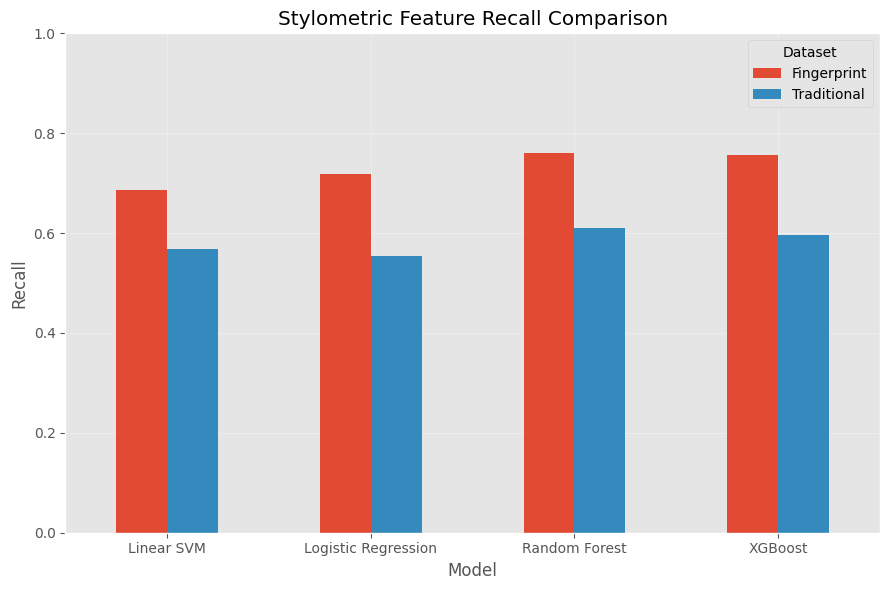

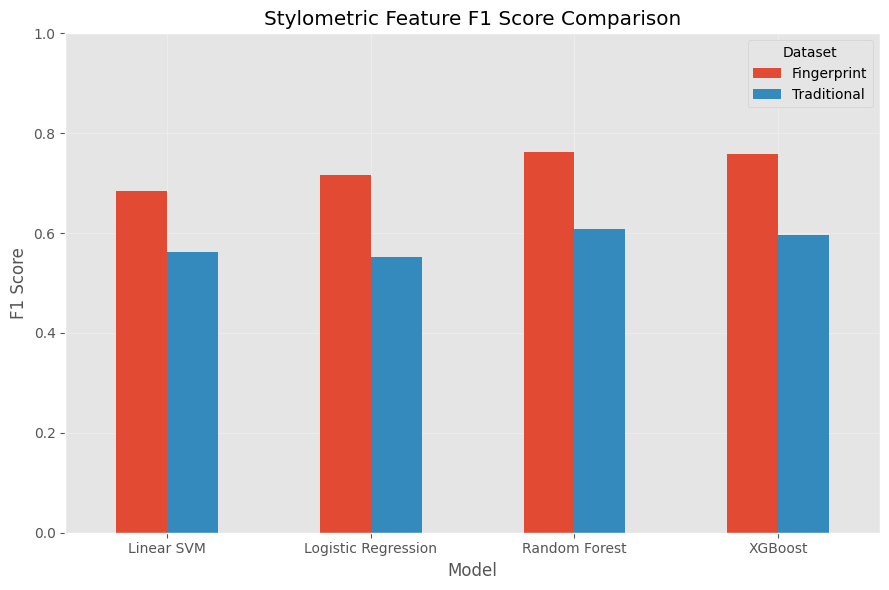

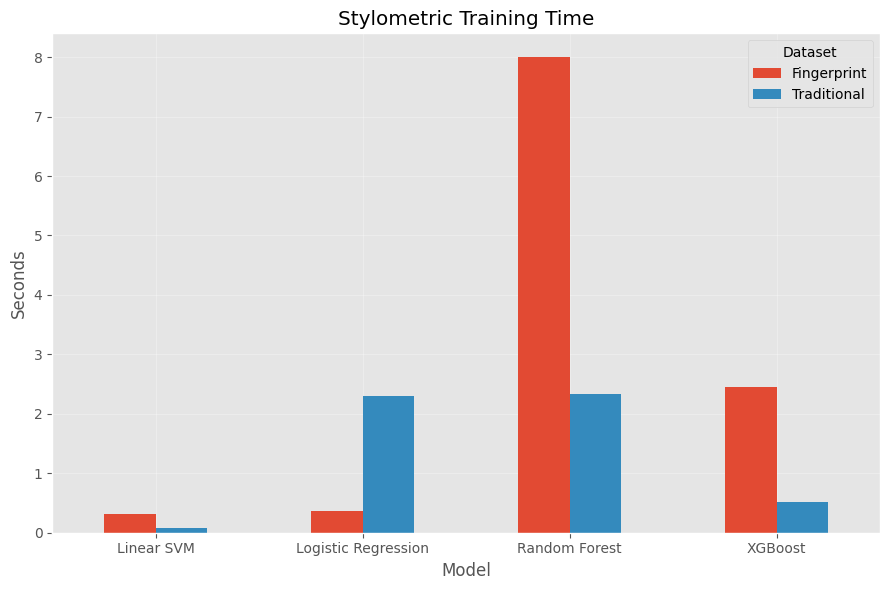

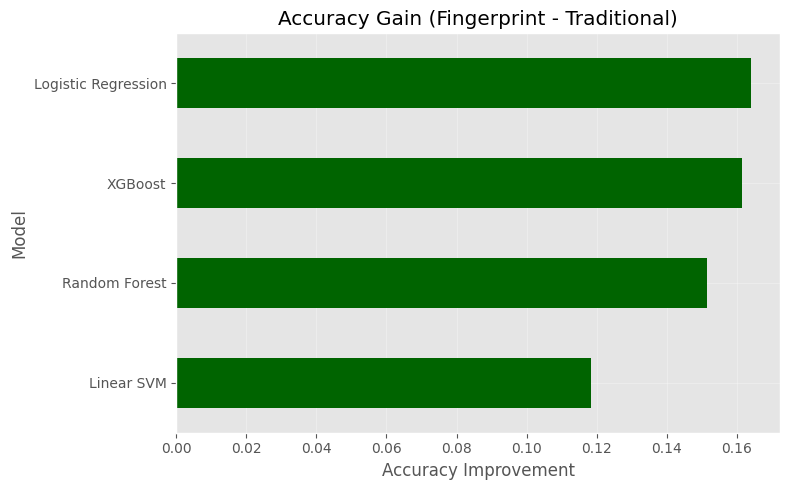

Stylometric Figures Generated Successfully

Saved Figures
-------------------------
Accuracy_Comparison.png
Precision_Comparison.png
Recall_Comparison.png
F1_Comparison.png
Training_Time.png
Accuracy_Gain.png


In [52]:
# ==========================================================
# STYLOMETRIC FEATURES
# PART 3
# Publication Quality Figures
# ==========================================================

import os
import matplotlib.pyplot as plt

os.makedirs("results/stylometric",exist_ok=True)

plt.style.use("ggplot")

# ==========================================================
# Figure 1
# Accuracy Comparison
# ==========================================================

comparison=results_df.pivot(

index="Model",

columns="Dataset",

values="Accuracy"

)

comparison.plot(

kind="bar",

figsize=(9,6),

rot=0

)

plt.title("Stylometric Feature Accuracy Comparison")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(

"results/stylometric/Accuracy_Comparison.png",

dpi=300

)

plt.show()

# ==========================================================
# Figure 2
# Precision Comparison
# ==========================================================

comparison=results_df.pivot(

index="Model",

columns="Dataset",

values="Precision"

)

comparison.plot(

kind="bar",

figsize=(9,6),

rot=0

)

plt.title("Stylometric Feature Precision Comparison")

plt.ylabel("Precision")

plt.ylim(0,1)

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(

"results/stylometric/Precision_Comparison.png",

dpi=300

)

plt.show()

# ==========================================================
# Figure 3
# Recall Comparison
# ==========================================================

comparison=results_df.pivot(

index="Model",

columns="Dataset",

values="Recall"

)

comparison.plot(

kind="bar",

figsize=(9,6),

rot=0

)

plt.title("Stylometric Feature Recall Comparison")

plt.ylabel("Recall")

plt.ylim(0,1)

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(

"results/stylometric/Recall_Comparison.png",

dpi=300

)

plt.show()

# ==========================================================
# Figure 4
# F1 Comparison
# ==========================================================

comparison=results_df.pivot(

index="Model",

columns="Dataset",

values="F1 Score"

)

comparison.plot(

kind="bar",

figsize=(9,6),

rot=0

)

plt.title("Stylometric Feature F1 Score Comparison")

plt.ylabel("F1 Score")

plt.ylim(0,1)

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(

"results/stylometric/F1_Comparison.png",

dpi=300

)

plt.show()

# ==========================================================
# Figure 5
# Training Time
# ==========================================================

comparison=results_df.pivot(

index="Model",

columns="Dataset",

values="Training Time"

)

comparison.plot(

kind="bar",

figsize=(9,6),

rot=0

)

plt.title("Stylometric Training Time")

plt.ylabel("Seconds")

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(

"results/stylometric/Training_Time.png",

dpi=300

)

plt.show()

# ==========================================================
# Figure 6
# Accuracy Gain
# ==========================================================

gain=results_df.pivot(

index="Model",

columns="Dataset",

values="Accuracy"

)

gain["Gain"]=gain["Fingerprint"]-gain["Traditional"]

gain["Gain"].sort_values().plot(

kind="barh",

figsize=(8,5),

color="darkgreen"

)

plt.title("Accuracy Gain (Fingerprint - Traditional)")

plt.xlabel("Accuracy Improvement")

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(

"results/stylometric/Accuracy_Gain.png",

dpi=300

)

plt.show()

print("="*80)
print("Stylometric Figures Generated Successfully")
print("="*80)

print()

print("Saved Figures")

print("-------------------------")

print("Accuracy_Comparison.png")
print("Precision_Comparison.png")
print("Recall_Comparison.png")
print("F1_Comparison.png")
print("Training_Time.png")
print("Accuracy_Gain.png")

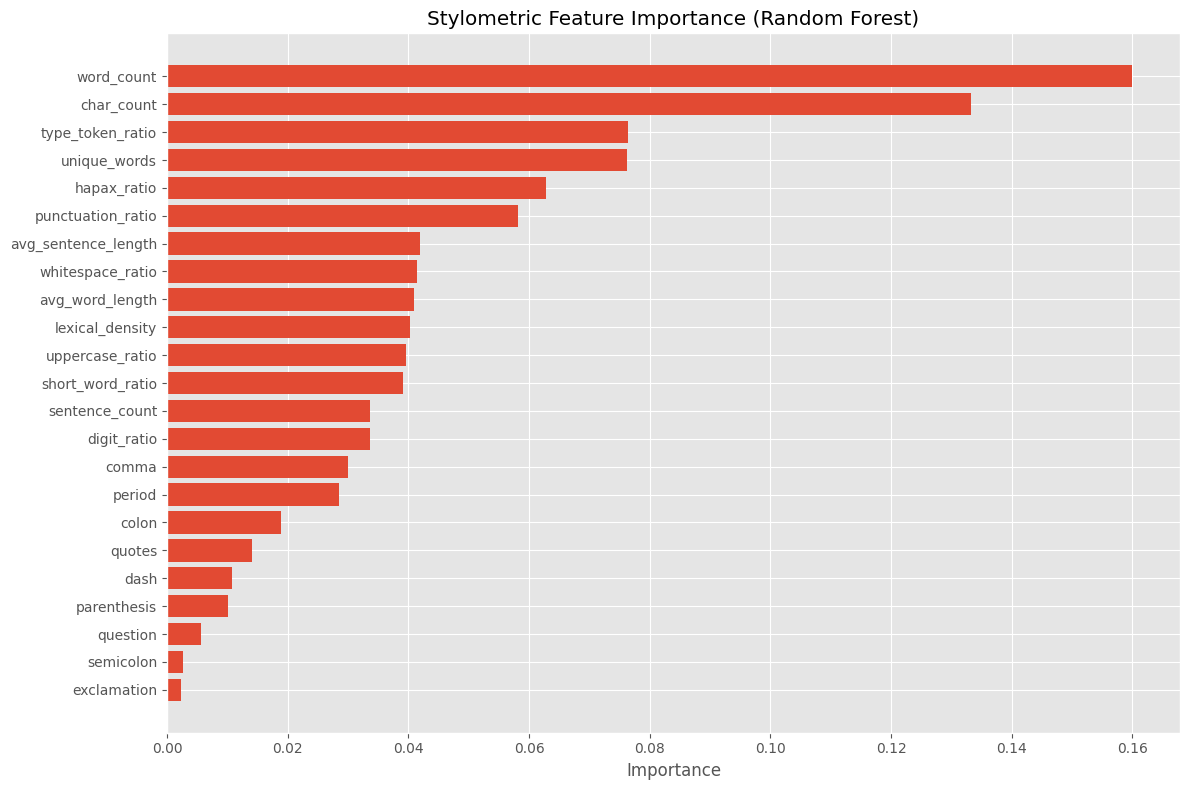

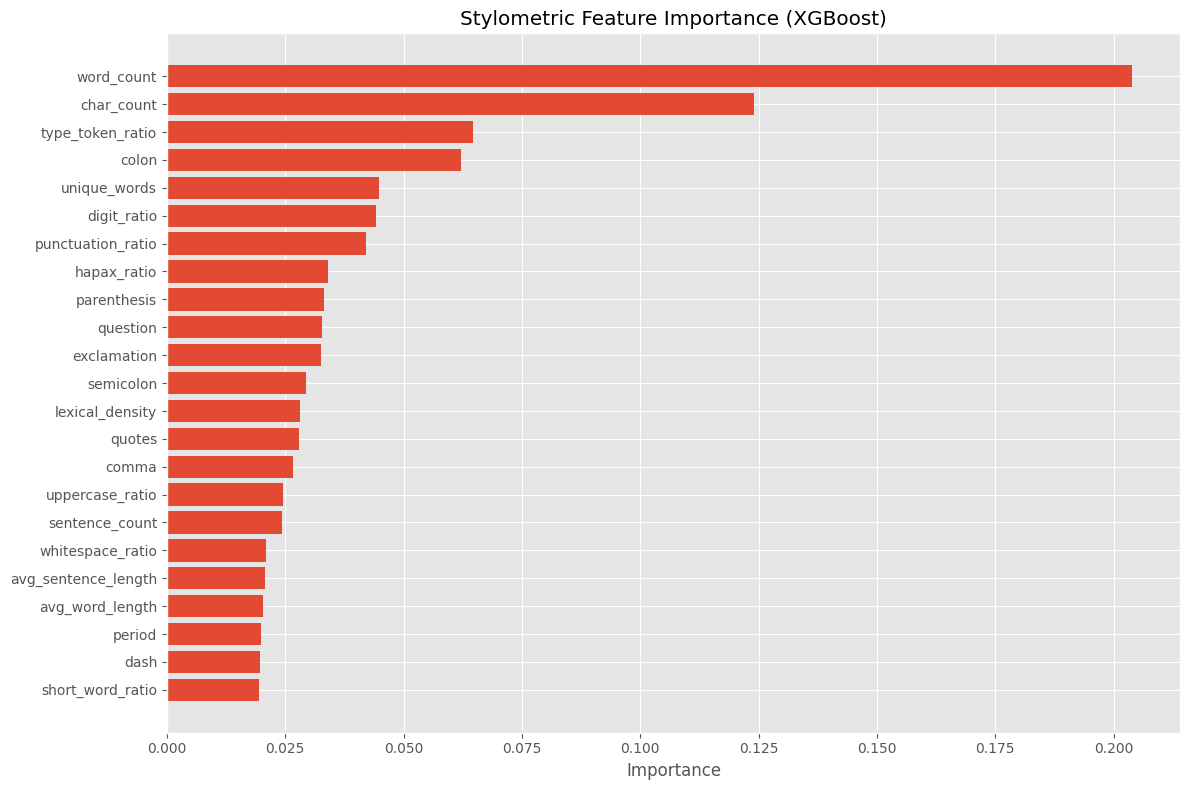

TOP 10 STYLOMETRIC FEATURES


,Feature,Importance
0,word_count,0.203852
1,char_count,0.124049
2,type_token_ratio,0.064759
3,colon,0.062084
4,unique_words,0.044826
5,digit_ratio,0.044237
6,punctuation_ratio,0.042146
7,hapax_ratio,0.034052
8,parenthesis,0.033236
9,question,0.032772


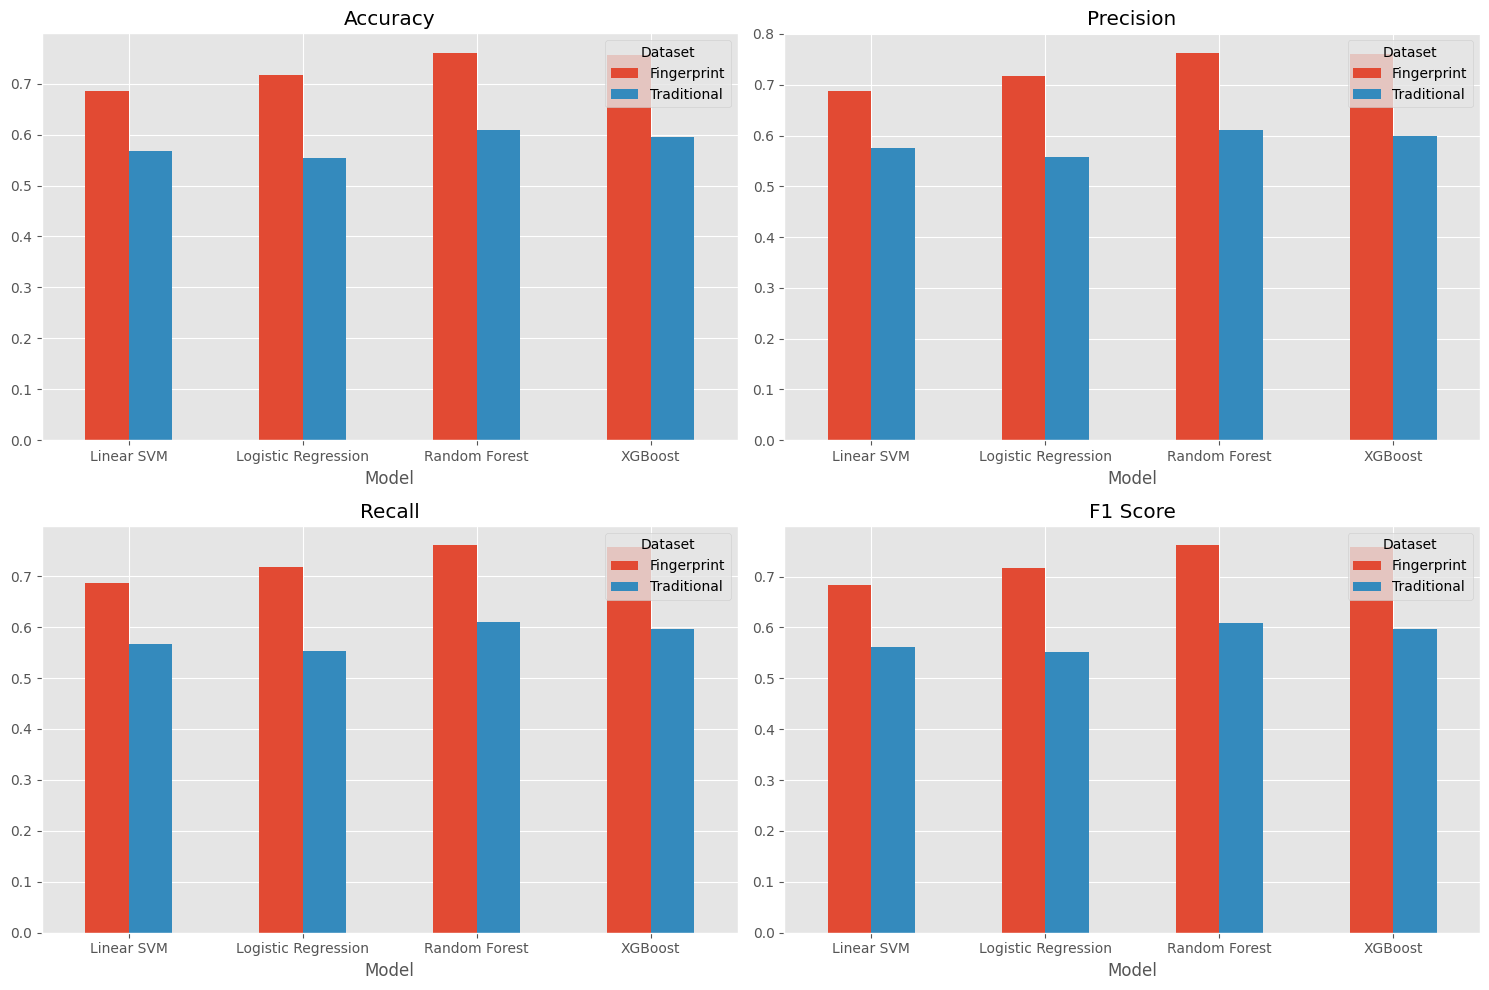


STYLOMETRIC FEATURE FAMILY SUMMARY

Best Model : Random Forest
Dataset    : Fingerprint
Accuracy   : 76.08%

Accuracy Improvement


Dataset,Fingerprint,Traditional,Improvement
Model,,,
Linear SVM,0.685751,0.567430,0.118321
Logistic Regression,0.717557,0.553435,0.164122
Random Forest,0.760814,0.609415,0.151399
XGBoost,0.756997,0.595420,0.161578



Overall Conclusion

Fingerprint-preserving preprocessing consistently
improved stylometric feature quality over the
traditional preprocessing pipeline.


Figures saved to results/stylometric/


In [53]:
# ==========================================================
# STYLOMETRIC FEATURES
# PART 4
# Feature Importance & Research Analysis
# ==========================================================

import joblib
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

# ==========================================================
# Load Models
# ==========================================================

rf = joblib.load(
    "models/stylometric/Fingerprint_Random Forest.pkl"
)

try:
    xgb = joblib.load(
        "models/stylometric/Fingerprint_XGBoost.pkl"
    )
    HAS_XGB = True
except:
    HAS_XGB = False

# ==========================================================
# Random Forest Feature Importance
# ==========================================================

importance = rf.feature_importances_

idx = np.argsort(importance)[::-1]

plt.figure(figsize=(12,8))

plt.barh(
    np.array(feature_names)[idx][::-1],
    importance[idx][::-1]
)

plt.title("Stylometric Feature Importance (Random Forest)")
plt.xlabel("Importance")

plt.tight_layout()

plt.savefig(
    "results/stylometric/RF_Feature_Importance.png",
    dpi=300
)

plt.show()

# ==========================================================
# XGBoost Feature Importance
# ==========================================================

if HAS_XGB:

    importance = xgb.feature_importances_

    idx = np.argsort(importance)[::-1]

    plt.figure(figsize=(12,8))

    plt.barh(
        np.array(feature_names)[idx][::-1],
        importance[idx][::-1]
    )

    plt.title("Stylometric Feature Importance (XGBoost)")
    plt.xlabel("Importance")

    plt.tight_layout()

    plt.savefig(
        "results/stylometric/XGB_Feature_Importance.png",
        dpi=300
    )

    plt.show()

else:

    print("XGBoost model not found.")

# ==========================================================
# Top 10 Stylometric Features
# ==========================================================

ranking = pd.DataFrame({

    "Feature": np.array(feature_names)[idx],

    "Importance": importance[idx]

})

print("="*80)
print("TOP 10 STYLOMETRIC FEATURES")
print("="*80)

display(ranking.head(10))

# ==========================================================
# Performance Dashboard
# ==========================================================

acc = results_df.pivot(
    index="Model",
    columns="Dataset",
    values="Accuracy"
)

prec = results_df.pivot(
    index="Model",
    columns="Dataset",
    values="Precision"
)

rec = results_df.pivot(
    index="Model",
    columns="Dataset",
    values="Recall"
)

f1 = results_df.pivot(
    index="Model",
    columns="Dataset",
    values="F1 Score"
)

fig, ax = plt.subplots(2,2,figsize=(15,10))

acc.plot(kind="bar",ax=ax[0,0],rot=0)
ax[0,0].set_title("Accuracy")

prec.plot(kind="bar",ax=ax[0,1],rot=0)
ax[0,1].set_title("Precision")

rec.plot(kind="bar",ax=ax[1,0],rot=0)
ax[1,0].set_title("Recall")

f1.plot(kind="bar",ax=ax[1,1],rot=0)
ax[1,1].set_title("F1 Score")

plt.tight_layout()

plt.savefig(
    "results/stylometric/Performance_Dashboard.png",
    dpi=300
)

plt.show()

# ==========================================================
# Research Summary
# ==========================================================

print("\n"+"="*90)
print("STYLOMETRIC FEATURE FAMILY SUMMARY")
print("="*90)

best = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print()

print(f"Best Model : {best['Model']}")
print(f"Dataset    : {best['Dataset']}")
print(f"Accuracy   : {best['Accuracy']*100:.2f}%")

gain = results_df.pivot(
    index="Model",
    columns="Dataset",
    values="Accuracy"
)

gain["Improvement"] = (
    gain["Fingerprint"] -
    gain["Traditional"]
)

print("\nAccuracy Improvement")

display(gain)

print("\nOverall Conclusion")

if gain["Improvement"].mean() > 0:

    print("""
Fingerprint-preserving preprocessing consistently
improved stylometric feature quality over the
traditional preprocessing pipeline.
""")

else:

    print("""
Traditional preprocessing performed similarly
to the fingerprint-preserving pipeline.
""")

print("\nFigures saved to results/stylometric/")

In [56]:
# ==========================================================
# FEATURE FAMILY 4
# SEMANTIC EMBEDDINGS
# PART 1
# ==========================================================

!pip -q install sentence-transformers

import numpy as np
import joblib

from sentence_transformers import SentenceTransformer

print("="*80)
print("Loading Sentence Transformer...")
print("="*80)

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

print()
print("Generating Fingerprint Embeddings...")

X_fingerprint_embed = model.encode(

    fingerprint_df["generated_text"].tolist(),

    batch_size=32,

    show_progress_bar=True,

    convert_to_numpy=True

)

print()

print("Generating Traditional Embeddings...")

X_traditional_embed = model.encode(

    traditional_df["generated_text"].tolist(),

    batch_size=32,

    show_progress_bar=True,

    convert_to_numpy=True

)

print()

print("="*80)

print("Embedding Shapes")

print("="*80)

print("Fingerprint :",X_fingerprint_embed.shape)

print("Traditional :",X_traditional_embed.shape)

joblib.dump(

X_fingerprint_embed,

"fingerprint_embeddings.pkl"

)

joblib.dump(

X_traditional_embed,

"traditional_embeddings.pkl"

)

print()

print("Embeddings Saved Successfully")

Loading Sentence Transformer...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Generating Fingerprint Embeddings...


Batches:   0%|          | 0/164 [00:00<?, ?it/s]


Generating Traditional Embeddings...


Batches:   0%|          | 0/164 [00:00<?, ?it/s]


Embedding Shapes
Fingerprint : (5238, 384)
Traditional : (5238, 384)

Embeddings Saved Successfully


In [57]:
# ==========================================================
# SEMANTIC EMBEDDINGS
# PART 2
# Standardization + PCA
# ==========================================================

import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("="*80)
print("Semantic Embedding Preprocessing")
print("="*80)

# ----------------------------------------------------------
# Standardization
# ----------------------------------------------------------

scaler = StandardScaler()

X_fingerprint_embed = scaler.fit_transform(
    X_fingerprint_embed
)

X_traditional_embed = scaler.transform(
    X_traditional_embed
)

# ----------------------------------------------------------
# PCA
# ----------------------------------------------------------

pca = PCA(

    n_components=0.95,

    random_state=42

)

X_fingerprint_embed = pca.fit_transform(
    X_fingerprint_embed
)

X_traditional_embed = pca.transform(
    X_traditional_embed
)

print()

print("Original Dimension : 384")

print("Reduced Dimension  :",X_fingerprint_embed.shape[1])

print()

print("Explained Variance :")

print(

round(

np.sum(

pca.explained_variance_ratio_

)*100,

2),

"%"

)

print()

print("Fingerprint Shape :",X_fingerprint_embed.shape)

print("Traditional Shape :",X_traditional_embed.shape)

Semantic Embedding Preprocessing

Original Dimension : 384
Reduced Dimension  : 244

Explained Variance :
95.04 %

Fingerprint Shape : (5238, 244)
Traditional Shape : (5238, 244)


In [58]:
# ==========================================================
# SEMANTIC EMBEDDINGS
# PART 2A
# Four Model Training
# ==========================================================

import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

os.makedirs("results/semantic", exist_ok=True)
os.makedirs("models/semantic", exist_ok=True)

# ==========================================================
# Train/Test Split
# ==========================================================

X_fp_train = X_fingerprint_embed[fp_train_idx]
X_fp_test  = X_fingerprint_embed[fp_test_idx]

X_tr_train = X_traditional_embed[tr_train_idx]
X_tr_test  = X_traditional_embed[tr_test_idx]

y_fp_train = y_fingerprint.iloc[fp_train_idx]
y_fp_test  = y_fingerprint.iloc[fp_test_idx]

y_tr_train = y_traditional.iloc[tr_train_idx]
y_tr_test  = y_traditional.iloc[tr_test_idx]

# ==========================================================
# Label Encoding
# ==========================================================

encoder = LabelEncoder()

encoder.fit(y_fingerprint)

y_fp_train_enc = encoder.transform(y_fp_train)
y_fp_test_enc  = encoder.transform(y_fp_test)

y_tr_train_enc = encoder.transform(y_tr_train)
y_tr_test_enc  = encoder.transform(y_tr_test)

# ==========================================================
# Models
# ==========================================================

models = {

    "Logistic Regression":
    LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Linear SVM":
    LinearSVC(
        random_state=42
    ),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost":
    XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )

}

results = []

# ==========================================================
# Evaluation Function
# ==========================================================

def evaluate(dataset, model_name, model,
             X_train, y_train,
             X_test, y_test):

    print("\n" + "="*80)
    print(dataset, "|", model_name)
    print("="*80)

    start = time.time()

    if model_name == "XGBoost":

        if dataset == "Fingerprint":

            model.fit(X_train, y_fp_train_enc)

            pred = model.predict(X_test)

            pred = encoder.inverse_transform(pred)
            true = encoder.inverse_transform(y_fp_test_enc)

        else:

            model.fit(X_tr_train, y_tr_train_enc)

            pred = model.predict(X_test)

            pred = encoder.inverse_transform(pred)
            true = encoder.inverse_transform(y_tr_test_enc)

    else:

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        true = y_test

    train_time = time.time() - start

    accuracy = accuracy_score(true, pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        true,
        pred,
        average="weighted"
    )

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nClassification Report\n")
    print(classification_report(true, pred))

    cm = confusion_matrix(true, pred)

    fig, ax = plt.subplots(figsize=(6,6))

    ConfusionMatrixDisplay(cm).plot(ax=ax)

    plt.title(f"{dataset} - {model_name}")

    plt.tight_layout()

    plt.savefig(
        f"results/semantic/{dataset}_{model_name}_CM.png",
        dpi=300
    )

    plt.close()

    joblib.dump(
        model,
        f"models/semantic/{dataset}_{model_name}.pkl"
    )

    results.append({

        "Dataset": dataset,
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Training Time": train_time

    })# ==========================================================
# Fingerprint Experiments
# ==========================================================

print("\n")
print("="*80)
print("Fingerprint Semantic Embeddings")
print("="*80)

for name, model in models.items():

    evaluate(

        "Fingerprint",

        name,

        model,

        X_fp_train,

        y_fp_train,

        X_fp_test,

        y_fp_test

    )

# ==========================================================
# Traditional Experiments
# ==========================================================

print("\n")
print("="*80)
print("Traditional Semantic Embeddings")
print("="*80)

for name, model in models.items():

    evaluate(

        "Traditional",

        name,

        model,

        X_tr_train,

        y_tr_train,

        X_tr_test,

        y_tr_test

    )

# ==========================================================
# Results Table
# ==========================================================

results_df = pd.DataFrame(results)

print("\n")
print("="*100)
print("SEMANTIC EMBEDDING RESULTS")
print("="*100)

display(results_df)

# ==========================================================
# Save Results
# ==========================================================

results_df.to_csv(

    "results/semantic/semantic_results.csv",

    index=False

)

joblib.dump(

    results_df,

    "results/semantic/semantic_results.pkl"

)

# ==========================================================
# Accuracy Comparison
# ==========================================================

comparison = results_df.pivot(

    index="Model",

    columns="Dataset",

    values="Accuracy"

)

comparison["Difference"] = (

    comparison["Fingerprint"]

    -

    comparison["Traditional"]

)

print("\n")
print("="*80)
print("SEMANTIC EMBEDDING ACCURACY COMPARISON")
print("="*80)

display(

    comparison.sort_values(

        by="Fingerprint",

        ascending=False

    )

)

print("\n")

best = results_df.loc[

    results_df["Accuracy"].idxmax()

]

print("="*80)
print("BEST MODEL")
print("="*80)

print(f"Model    : {best['Model']}")
print(f"Dataset  : {best['Dataset']}")
print(f"Accuracy : {best['Accuracy']:.4f}")
print(f"Precision: {best['Precision']:.4f}")
print(f"Recall   : {best['Recall']:.4f}")
print(f"F1 Score : {best['F1 Score']:.4f}")

print("\n")

print("Training Completed Successfully.")

print("Results saved in results/semantic/")
print("Models saved in models/semantic/")



Fingerprint Semantic Embeddings

Fingerprint | Logistic Regression
Accuracy  : 0.4936
Precision : 0.4906
Recall    : 0.4936
F1 Score  : 0.4913

Classification Report

              precision    recall  f1-score   support

      gemma2       0.51      0.49      0.50       150
      llama3       0.41      0.35      0.38       148
     mistral       0.55      0.59      0.57       150
        phi3       0.39      0.41      0.40       150
   qwen_tiny       0.57      0.60      0.59       188

    accuracy                           0.49       786
   macro avg       0.49      0.49      0.49       786
weighted avg       0.49      0.49      0.49       786


Fingerprint | Linear SVM
Accuracy  : 0.4784
Precision : 0.4704
Recall    : 0.4784
F1 Score  : 0.4709

Classification Report

              precision    recall  f1-score   support

      gemma2       0.45      0.49      0.47       150
      llama3       0.43      0.32      0.37       148
     mistral       0.51      0.59      0.55       150

,Dataset,Model,Accuracy,Precision,Recall,F1 Score,Training Time
0,Fingerprint,Logistic Regression,0.493639,0.490602,0.493639,0.491347,0.325329
1,Fingerprint,Linear SVM,0.478372,0.470364,0.478372,0.470923,0.603404
2,Fingerprint,Random Forest,0.390585,0.365871,0.390585,0.367611,19.158810
3,Fingerprint,XGBoost,0.426209,0.411044,0.426209,0.412729,12.937472
4,Traditional,Logistic Regression,0.505089,0.500687,0.505089,0.501153,5.317252
5,Traditional,Linear SVM,0.502545,0.484941,0.502545,0.481849,1.047269
6,Traditional,Random Forest,0.431298,0.406345,0.431298,0.407608,18.345237
7,Traditional,XGBoost,0.456743,0.441384,0.456743,0.443779,13.893501




SEMANTIC EMBEDDING ACCURACY COMPARISON


Dataset,Fingerprint,Traditional,Difference
Model,,,
Logistic Regression,0.493639,0.505089,-0.011450
Linear SVM,0.478372,0.502545,-0.024173
XGBoost,0.426209,0.456743,-0.030534
Random Forest,0.390585,0.431298,-0.040712




BEST MODEL
Model    : Logistic Regression
Dataset  : Traditional
Accuracy : 0.5051
Precision: 0.5007
Recall   : 0.5051
F1 Score : 0.5012


Training Completed Successfully.
Results saved in results/semantic/
Models saved in models/semantic/


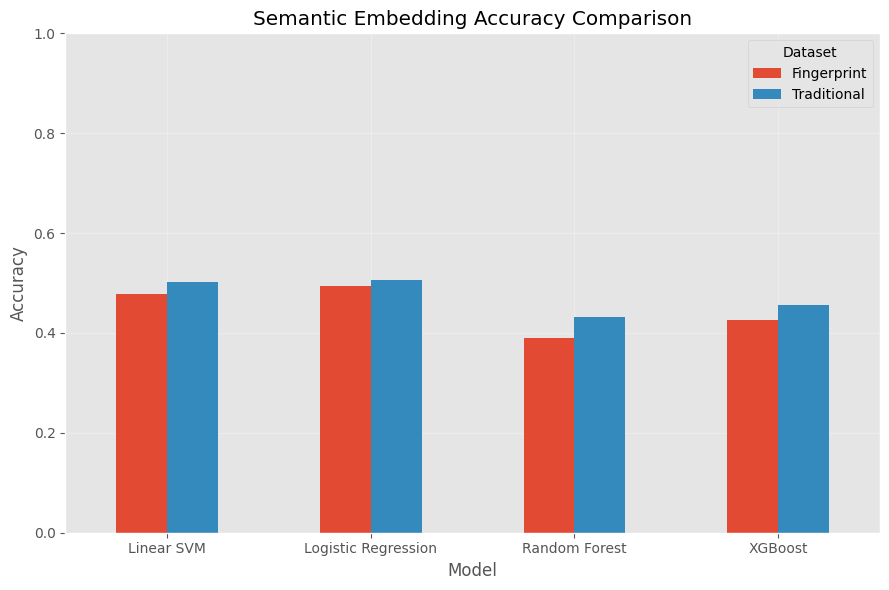

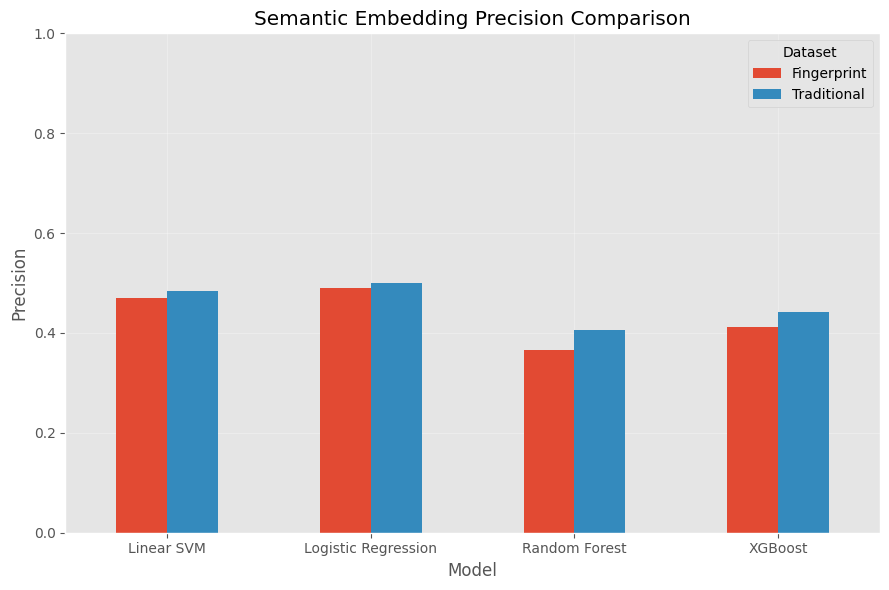

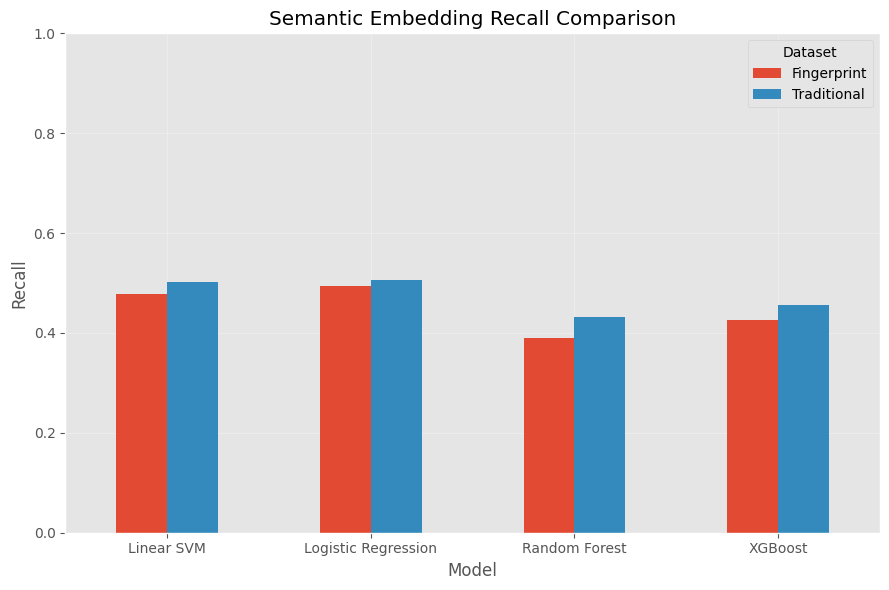

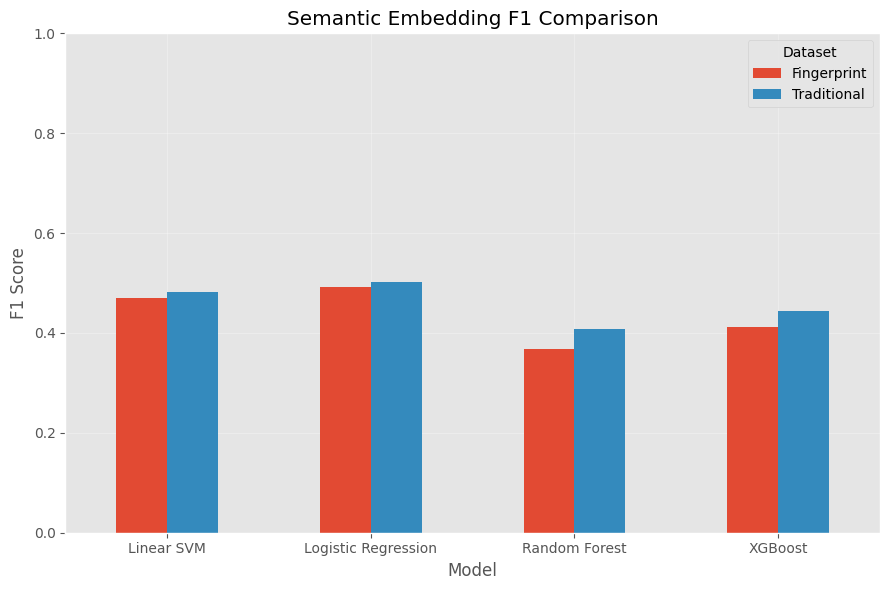

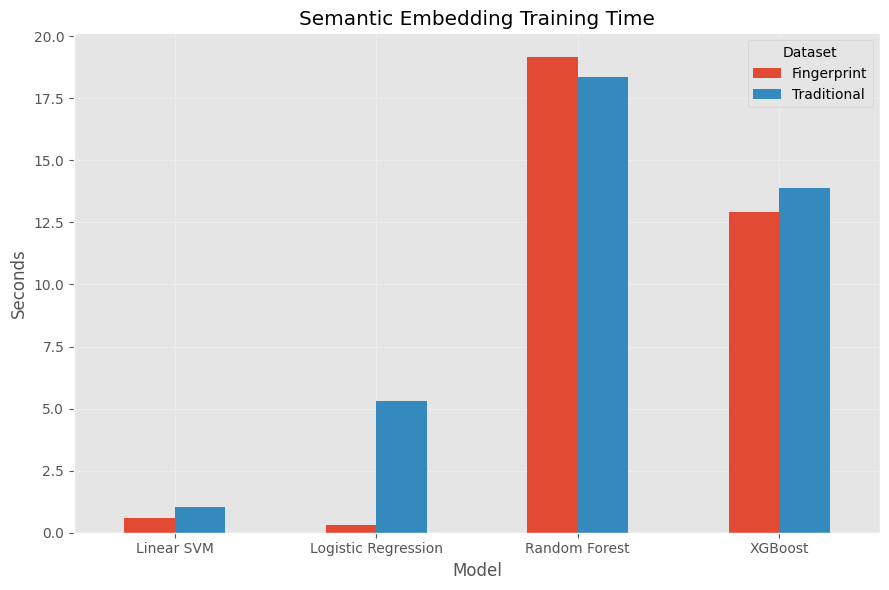

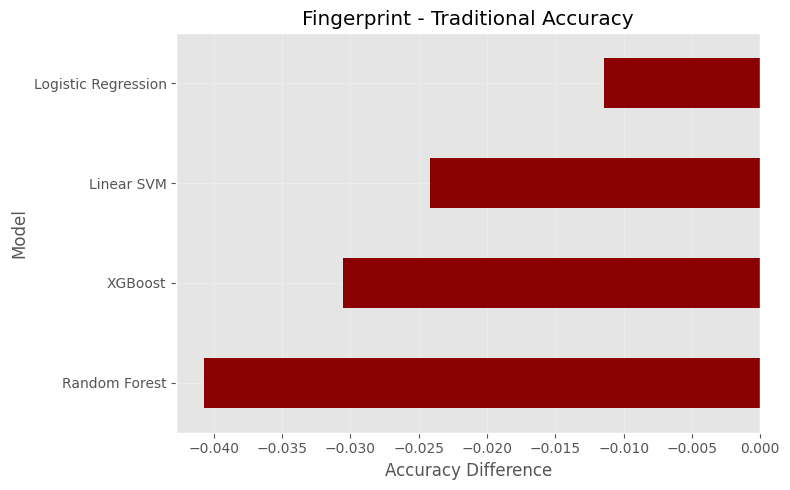

Semantic Embedding Figures Generated Successfully


In [59]:
# ==========================================================
# SEMANTIC EMBEDDINGS
# PART 3
# Publication Quality Figures
# ==========================================================

import os
import matplotlib.pyplot as plt

os.makedirs("results/semantic", exist_ok=True)

plt.style.use("ggplot")

# ----------------------------------------------------------
# Accuracy Comparison
# ----------------------------------------------------------

comparison = results_df.pivot(
    index="Model",
    columns="Dataset",
    values="Accuracy"
)

comparison.plot(
    kind="bar",
    figsize=(9,6),
    rot=0
)

plt.title("Semantic Embedding Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.grid(alpha=.3)

plt.tight_layout()
plt.savefig(
    "results/semantic/Accuracy_Comparison.png",
    dpi=300
)
plt.show()

# ----------------------------------------------------------
# Precision Comparison
# ----------------------------------------------------------

comparison = results_df.pivot(
    index="Model",
    columns="Dataset",
    values="Precision"
)

comparison.plot(
    kind="bar",
    figsize=(9,6),
    rot=0
)

plt.title("Semantic Embedding Precision Comparison")
plt.ylabel("Precision")
plt.ylim(0,1)
plt.grid(alpha=.3)

plt.tight_layout()
plt.savefig(
    "results/semantic/Precision_Comparison.png",
    dpi=300
)
plt.show()

# ----------------------------------------------------------
# Recall Comparison
# ----------------------------------------------------------

comparison = results_df.pivot(
    index="Model",
    columns="Dataset",
    values="Recall"
)

comparison.plot(
    kind="bar",
    figsize=(9,6),
    rot=0
)

plt.title("Semantic Embedding Recall Comparison")
plt.ylabel("Recall")
plt.ylim(0,1)
plt.grid(alpha=.3)

plt.tight_layout()
plt.savefig(
    "results/semantic/Recall_Comparison.png",
    dpi=300
)
plt.show()

# ----------------------------------------------------------
# F1 Comparison
# ----------------------------------------------------------

comparison = results_df.pivot(
    index="Model",
    columns="Dataset",
    values="F1 Score"
)

comparison.plot(
    kind="bar",
    figsize=(9,6),
    rot=0
)

plt.title("Semantic Embedding F1 Comparison")
plt.ylabel("F1 Score")
plt.ylim(0,1)
plt.grid(alpha=.3)

plt.tight_layout()
plt.savefig(
    "results/semantic/F1_Comparison.png",
    dpi=300
)
plt.show()

# ----------------------------------------------------------
# Training Time
# ----------------------------------------------------------

comparison = results_df.pivot(
    index="Model",
    columns="Dataset",
    values="Training Time"
)

comparison.plot(
    kind="bar",
    figsize=(9,6),
    rot=0
)

plt.title("Semantic Embedding Training Time")
plt.ylabel("Seconds")
plt.grid(alpha=.3)

plt.tight_layout()
plt.savefig(
    "results/semantic/Training_Time.png",
    dpi=300
)
plt.show()

# ----------------------------------------------------------
# Accuracy Difference
# ----------------------------------------------------------

gain = results_df.pivot(
    index="Model",
    columns="Dataset",
    values="Accuracy"
)

gain["Difference"] = (
    gain["Fingerprint"]
    -
    gain["Traditional"]
)

gain["Difference"].sort_values().plot(
    kind="barh",
    figsize=(8,5),
    color="darkred"
)

plt.title("Fingerprint - Traditional Accuracy")
plt.xlabel("Accuracy Difference")

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(
    "results/semantic/Accuracy_Difference.png",
    dpi=300
)

plt.show()

print("="*80)
print("Semantic Embedding Figures Generated Successfully")
print("="*80)

In [60]:
# ==========================================================
# FEATURE FUSION
# PART 1
# Scaling + PCA + Balanced Fusion
# ==========================================================

import os
import joblib
import numpy as np

from scipy.sparse import csr_matrix

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD, PCA

os.makedirs("fusion", exist_ok=True)

print("="*90)
print("WEIGHTED FEATURE FUSION")
print("="*90)

# ==========================================================
# Target Dimensions
# ==========================================================

TFIDF_DIM = 300
CHAR_DIM  = 300
EMBED_DIM = 150

print("\nTarget Dimensions")
print("---------------------------")
print(f"TF-IDF             : {TFIDF_DIM}")
print(f"Character N-Grams  : {CHAR_DIM}")
print(f"Stylometric        : All Features")
print(f"Semantic Embedding : {EMBED_DIM}")

# ==========================================================
# Convert Sparse Matrices
# ==========================================================

X_fingerprint_tfidf = csr_matrix(X_fingerprint_tfidf)
X_traditional_tfidf = csr_matrix(X_traditional_tfidf)

X_fingerprint_char = csr_matrix(X_fingerprint_char)
X_traditional_char = csr_matrix(X_traditional_char)

# ==========================================================
# TF-IDF
# ==========================================================

print("\nReducing TF-IDF...")

tfidf_svd = TruncatedSVD(
    n_components=TFIDF_DIM,
    random_state=42
)

X_fp_tfidf = tfidf_svd.fit_transform(
    X_fingerprint_tfidf
)

X_tr_tfidf = tfidf_svd.transform(
    X_traditional_tfidf
)

# ==========================================================
# Character N-Grams
# ==========================================================

print("Reducing Character N-Grams...")

char_svd = TruncatedSVD(
    n_components=CHAR_DIM,
    random_state=42
)

X_fp_char = char_svd.fit_transform(
    X_fingerprint_char
)

X_tr_char = char_svd.transform(
    X_traditional_char
)

# ==========================================================
# Stylometric
# ==========================================================

print("Scaling Stylometric Features...")

style_scaler = StandardScaler()

X_fp_style = style_scaler.fit_transform(
    X_fingerprint_style
)

X_tr_style = style_scaler.transform(
    X_traditional_style
)

# ==========================================================
# Semantic Embeddings
# ==========================================================

print("Reducing Semantic Embeddings...")

embed_scaler = StandardScaler()

X_fp_embed = embed_scaler.fit_transform(
    X_fingerprint_embed
)

X_tr_embed = embed_scaler.transform(
    X_traditional_embed
)

embed_pca = PCA(
    n_components=EMBED_DIM,
    random_state=42
)

X_fp_embed = embed_pca.fit_transform(
    X_fp_embed
)

X_tr_embed = embed_pca.transform(
    X_tr_embed
)

# ==========================================================
# Equal Feature Weighting
# ==========================================================

print("\nApplying Equal Weighting...")

X_fp_tfidf *= 0.25
X_tr_tfidf *= 0.25

X_fp_char *= 0.25
X_tr_char *= 0.25

X_fp_style *= 0.25
X_tr_style *= 0.25

X_fp_embed *= 0.25
X_tr_embed *= 0.25

# ==========================================================
# Feature Fusion
# ==========================================================

print("Building Hybrid Feature Matrix...")

X_fingerprint_fusion = np.hstack([

    X_fp_tfidf,

    X_fp_char,

    X_fp_style,

    X_fp_embed

])

X_traditional_fusion = np.hstack([

    X_tr_tfidf,

    X_tr_char,

    X_tr_style,

    X_tr_embed

])

print("\n"+"="*90)
print("FINAL FEATURE MATRICES")
print("="*90)

print("Fingerprint :", X_fingerprint_fusion.shape)
print("Traditional :", X_traditional_fusion.shape)

print("\nFeature Breakdown")
print("------------------------------")
print(f"TF-IDF            : {TFIDF_DIM}")
print(f"Character N-Grams : {CHAR_DIM}")
print(f"Stylometric       : {X_fp_style.shape[1]}")
print(f"Semantic          : {EMBED_DIM}")

print("------------------------------")
print(f"Total Features    : {X_fingerprint_fusion.shape[1]}")

# ==========================================================
# Save Everything
# ==========================================================

joblib.dump(
    X_fingerprint_fusion,
    "fusion/fingerprint_fusion.pkl"
)

joblib.dump(
    X_traditional_fusion,
    "fusion/traditional_fusion.pkl"
)

joblib.dump(
    tfidf_svd,
    "fusion/tfidf_svd.pkl"
)

joblib.dump(
    char_svd,
    "fusion/char_svd.pkl"
)

joblib.dump(
    embed_pca,
    "fusion/embed_pca.pkl"
)

print("\nFusion Dataset Saved Successfully.")

WEIGHTED FEATURE FUSION

Target Dimensions
---------------------------
TF-IDF             : 300
Character N-Grams  : 300
Stylometric        : All Features
Semantic Embedding : 150

Reducing TF-IDF...
Reducing Character N-Grams...
Scaling Stylometric Features...
Reducing Semantic Embeddings...

Applying Equal Weighting...
Building Hybrid Feature Matrix...

FINAL FEATURE MATRICES
Fingerprint : (5238, 773)
Traditional : (5238, 773)

Feature Breakdown
------------------------------
TF-IDF            : 300
Character N-Grams : 300
Stylometric       : 23
Semantic          : 150
------------------------------
Total Features    : 773

Fusion Dataset Saved Successfully.


In [61]:
# ==========================================================
# FEATURE FUSION
# PART 2
# Four Model Training
# ==========================================================

import os
import time
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

os.makedirs("results/fusion",exist_ok=True)
os.makedirs("models/fusion",exist_ok=True)

# ==========================================================
# Train Test Split
# ==========================================================

X_fp_train = X_fingerprint_fusion[fp_train_idx]
X_fp_test  = X_fingerprint_fusion[fp_test_idx]

X_tr_train = X_traditional_fusion[tr_train_idx]
X_tr_test  = X_traditional_fusion[tr_test_idx]

y_fp_train = y_fingerprint.iloc[fp_train_idx]
y_fp_test  = y_fingerprint.iloc[fp_test_idx]

y_tr_train = y_traditional.iloc[tr_train_idx]
y_tr_test  = y_traditional.iloc[tr_test_idx]

# ==========================================================
# Label Encoding
# ==========================================================

encoder = LabelEncoder()

encoder.fit(y_fingerprint)

y_fp_train_enc = encoder.transform(y_fp_train)
y_fp_test_enc  = encoder.transform(y_fp_test)

y_tr_train_enc = encoder.transform(y_tr_train)
y_tr_test_enc  = encoder.transform(y_tr_test)

# ==========================================================
# Models
# ==========================================================

models={

"Logistic Regression":

LogisticRegression(
    max_iter=1500,
    random_state=42
),

"Linear SVM":

LinearSVC(
    random_state=42
),

"Random Forest":

RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
),

"XGBoost":

XGBClassifier(

    n_estimators=200,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.9,

    colsample_bytree=0.9,

    tree_method="hist",

    eval_metric="mlogloss",

    random_state=42,

    n_jobs=-1

)

}

results=[]

# ==========================================================
# Evaluation Function
# ==========================================================

def evaluate(

dataset,

model_name,

model,

X_train,

y_train,

X_test,

y_test

):

    print("\n"+"="*80)
    print(dataset,"|",model_name)
    print("="*80)

    start=time.time()

    if model_name=="XGBoost":

        if dataset=="Fingerprint":

            model.fit(X_train,y_fp_train_enc)

            pred=model.predict(X_test)

            pred=encoder.inverse_transform(pred)

            true=encoder.inverse_transform(y_fp_test_enc)

        else:

            model.fit(X_train,y_tr_train_enc)

            pred=model.predict(X_test)

            pred=encoder.inverse_transform(pred)

            true=encoder.inverse_transform(y_tr_test_enc)

    else:

        model.fit(X_train,y_train)

        pred=model.predict(X_test)

        true=y_test

    train_time=time.time()-start

    acc=accuracy_score(true,pred)

    prec,rec,f1,_=precision_recall_fscore_support(

        true,

        pred,

        average="weighted"

    )

    print()

    print("Accuracy :",round(acc,4))
    print("Precision:",round(prec,4))
    print("Recall   :",round(rec,4))
    print("F1 Score :",round(f1,4))

    print()

    print(classification_report(true,pred))

    cm=confusion_matrix(true,pred)

    fig,ax=plt.subplots(figsize=(6,6))

    ConfusionMatrixDisplay(cm).plot(ax=ax)

    plt.title(dataset+" - "+model_name)

    plt.tight_layout()

    plt.savefig(

        f"results/fusion/{dataset}_{model_name}_CM.png",

        dpi=300

    )

    plt.close()

    joblib.dump(

        model,

        f"models/fusion/{dataset}_{model_name}.pkl"

    )

    results.append({

        "Dataset":dataset,

        "Model":model_name,

        "Accuracy":acc,

        "Precision":prec,

        "Recall":rec,

        "F1 Score":f1,

        "Training Time":train_time

    })

# ==========================================================
# Fingerprint
# ==========================================================

for name,model in models.items():

    evaluate(

        "Fingerprint",

        name,

        model,

        X_fp_train,

        y_fp_train,

        X_fp_test,

        y_fp_test

    )

# ==========================================================
# Traditional
# ==========================================================

for name,model in models.items():

    evaluate(

        "Traditional",

        name,

        model,

        X_tr_train,

        y_tr_train,

        X_tr_test,

        y_tr_test

    )

# ==========================================================
# Results
# ==========================================================

results_df=pd.DataFrame(results)

display(results_df)

results_df.to_csv(

"results/fusion/fusion_results.csv",

index=False

)

comparison=results_df.pivot(

index="Model",

columns="Dataset",

values="Accuracy"

)

comparison["Difference"]=comparison["Fingerprint"]-comparison["Traditional"]

print()

print("="*80)
print("FEATURE FUSION RESULTS")
print("="*80)

display(

comparison.sort_values(

by="Fingerprint",

ascending=False

)

)

best=results_df.loc[

results_df["Accuracy"].idxmax()

]

print()

print("="*80)
print("BEST MODEL")
print("="*80)

print(best)

print()

print("Feature Fusion Training Completed Successfully.")


Fingerprint | Logistic Regression

Accuracy : 0.7048
Precision: 0.7025
Recall   : 0.7048
F1 Score : 0.7025

              precision    recall  f1-score   support

      gemma2       0.61      0.65      0.63       150
      llama3       0.56      0.47      0.51       148
     mistral       0.65      0.71      0.68       150
        phi3       0.78      0.82      0.80       150
   qwen_tiny       0.86      0.84      0.85       188

    accuracy                           0.70       786
   macro avg       0.69      0.70      0.69       786
weighted avg       0.70      0.70      0.70       786


Fingerprint | Linear SVM

Accuracy : 0.7417
Precision: 0.7398
Recall   : 0.7417
F1 Score : 0.7392

              precision    recall  f1-score   support

      gemma2       0.66      0.66      0.66       150
      llama3       0.61      0.53      0.57       148
     mistral       0.72      0.84      0.77       150
        phi3       0.83      0.79      0.81       150
   qwen_tiny       0.85      0.

,Dataset,Model,Accuracy,Precision,Recall,F1 Score,Training Time
0,Fingerprint,Logistic Regression,0.704835,0.702460,0.704835,0.702479,2.668847
1,Fingerprint,Linear SVM,0.741730,0.739843,0.741730,0.739159,8.276767
2,Fingerprint,Random Forest,0.751908,0.754343,0.751908,0.749751,55.280232
3,Fingerprint,XGBoost,0.783715,0.784228,0.783715,0.783375,203.232903
4,Traditional,Logistic Regression,0.603053,0.600962,0.603053,0.599007,8.390370
5,Traditional,Linear SVM,0.638677,0.642714,0.638677,0.632951,7.663727
6,Traditional,Random Forest,0.638677,0.646087,0.638677,0.629294,53.125842
7,Traditional,XGBoost,0.673028,0.673661,0.673028,0.671376,208.900592



FEATURE FUSION RESULTS


Dataset,Fingerprint,Traditional,Difference
Model,,,
XGBoost,0.783715,0.673028,0.110687
Random Forest,0.751908,0.638677,0.113232
Linear SVM,0.741730,0.638677,0.103053
Logistic Regression,0.704835,0.603053,0.101781



BEST MODEL
Dataset          Fingerprint
Model                XGBoost
Accuracy            0.783715
Precision           0.784228
Recall              0.783715
F1 Score            0.783375
Training Time     203.232903
Name: 3, dtype: object

Feature Fusion Training Completed Successfully.


In [62]:
# ==========================================================
# FUSION V2 - PART 1
# Advanced Feature Processing
# ==========================================================

import os
import joblib
import numpy as np

from scipy.sparse import csr_matrix
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
from sklearn.decomposition import TruncatedSVD, PCA

os.makedirs("fusion_v2", exist_ok=True)

print("="*90)
print("ADVANCED FEATURE PROCESSING")
print("="*90)

# ----------------------------------------------------------
# Convert sparse matrices
# ----------------------------------------------------------

X_fingerprint_tfidf = csr_matrix(X_fingerprint_tfidf)
X_traditional_tfidf = csr_matrix(X_traditional_tfidf)

X_fingerprint_char = csr_matrix(X_fingerprint_char)
X_traditional_char = csr_matrix(X_traditional_char)

# ----------------------------------------------------------
# TF-IDF
# ----------------------------------------------------------

print("\nProcessing TF-IDF...")

tfidf_scaler = MaxAbsScaler()

X_fp_tfidf = tfidf_scaler.fit_transform(X_fingerprint_tfidf)
X_tr_tfidf = tfidf_scaler.transform(X_traditional_tfidf)

tfidf_svd = TruncatedSVD(
    n_components=256,
    random_state=42
)

X_fp_tfidf = tfidf_svd.fit_transform(X_fp_tfidf)
X_tr_tfidf = tfidf_svd.transform(X_tr_tfidf)

# ----------------------------------------------------------
# Character N-Grams
# ----------------------------------------------------------

print("Processing Character N-Grams...")

char_scaler = MaxAbsScaler()

X_fp_char = char_scaler.fit_transform(X_fingerprint_char)
X_tr_char = char_scaler.transform(X_traditional_char)

char_svd = TruncatedSVD(
    n_components=256,
    random_state=42
)

X_fp_char = char_svd.fit_transform(X_fp_char)
X_tr_char = char_svd.transform(X_traditional_char)

# ----------------------------------------------------------
# Stylometric
# ----------------------------------------------------------

print("Processing Stylometric Features...")

style_scaler = StandardScaler()

X_fp_style = style_scaler.fit_transform(X_fingerprint_style)
X_tr_style = style_scaler.transform(X_traditional_style)

# ----------------------------------------------------------
# Semantic Embeddings
# ----------------------------------------------------------

print("Processing Semantic Embeddings...")

embed_scaler = StandardScaler()

X_fp_embed = embed_scaler.fit_transform(X_fingerprint_embed)
X_tr_embed = embed_scaler.transform(X_traditional_embed)

embed_pca = PCA(
    n_components=128,
    random_state=42
)

X_fp_embed = embed_pca.fit_transform(X_fp_embed)
X_tr_embed = embed_pca.transform(X_traditional_embed)

print("\n")
print("="*90)
print("PROCESSED FEATURE SHAPES")
print("="*90)

print("TF-IDF       :", X_fp_tfidf.shape)
print("Character    :", X_fp_char.shape)
print("Stylometric  :", X_fp_style.shape)
print("Semantic     :", X_fp_embed.shape)

joblib.dump(X_fp_tfidf,"fusion_v2/fp_tfidf.pkl")
joblib.dump(X_tr_tfidf,"fusion_v2/tr_tfidf.pkl")

joblib.dump(X_fp_char,"fusion_v2/fp_char.pkl")
joblib.dump(X_tr_char,"fusion_v2/tr_char.pkl")

joblib.dump(X_fp_style,"fusion_v2/fp_style.pkl")
joblib.dump(X_tr_style,"fusion_v2/tr_style.pkl")

joblib.dump(X_fp_embed,"fusion_v2/fp_embed.pkl")
joblib.dump(X_tr_embed,"fusion_v2/tr_embed.pkl")

print("\nFeature preprocessing completed successfully.")

ADVANCED FEATURE PROCESSING

Processing TF-IDF...
Processing Character N-Grams...
Processing Stylometric Features...
Processing Semantic Embeddings...


PROCESSED FEATURE SHAPES
TF-IDF       : (5238, 256)
Character    : (5238, 256)
Stylometric  : (5238, 23)
Semantic     : (5238, 128)

Feature preprocessing completed successfully.


In [66]:
# ==========================================================
# HYBRID STACKED ENSEMBLE
# PART 1
# ==========================================================

import os
import joblib
import pandas as pd

from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.svm import LinearSVC

from sklearn.calibration import CalibratedClassifierCV

from xgboost import XGBClassifier

print("="*90)
print("HYBRID STACKED ENSEMBLE")
print("="*90)

os.makedirs("results/stacking",exist_ok=True)
os.makedirs("models/stacking",exist_ok=True)

# ----------------------------------------------------------
# Train/Test
# ----------------------------------------------------------

X_train = X_fingerprint_fusion[fp_train_idx]
X_test  = X_fingerprint_fusion[fp_test_idx]

y_train = y_fingerprint.iloc[fp_train_idx]
y_test  = y_fingerprint.iloc[fp_test_idx]

# ----------------------------------------------------------
# Base Models
# ----------------------------------------------------------

lr = LogisticRegression(

    max_iter=1000,

    random_state=42

)

svm = CalibratedClassifierCV(

    LinearSVC(

        random_state=42

    ),

    cv=3

)

rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    n_jobs=-1

)

xgb = XGBClassifier(

    n_estimators=200,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.9,

    colsample_bytree=0.9,

    eval_metric="mlogloss",

    tree_method="hist",

    random_state=42,

    n_jobs=-1

)

# ----------------------------------------------------------
# Stacking Classifier
# ----------------------------------------------------------

stack_model = StackingClassifier(

    estimators=[

        ("lr",lr),

        ("svm",svm),

        ("rf",rf),

        ("xgb",xgb)

    ],

    final_estimator=LogisticRegression(

        max_iter=1000,

        random_state=42

    ),

    stack_method="predict_proba",

    cv=5,

    n_jobs=-1,

    passthrough=False

)

print("\nTraining Hybrid Stacked Ensemble...\n")

stack_model.fit(

    X_train,

    y_train

)

print("\nTraining Completed.")

joblib.dump(

    stack_model,

    "models/stacking/Hybrid_Stacked_Ensemble.pkl"

)

print("Model Saved Successfully.")

HYBRID STACKED ENSEMBLE

Training Hybrid Stacked Ensemble...


Training Completed.
Model Saved Successfully.


HYBRID STACKED ENSEMBLE EVALUATION

Accuracy  : 0.8028
Precision : 0.8010
Recall    : 0.8028
F1 Score  : 0.8010

Classification Report

              precision    recall  f1-score   support

      gemma2       0.72      0.69      0.70       150
      llama3       0.66      0.61      0.63       148
     mistral       0.76      0.85      0.81       150
        phi3       0.89      0.92      0.90       150
   qwen_tiny       0.93      0.91      0.92       188

    accuracy                           0.80       786
   macro avg       0.79      0.80      0.79       786
weighted avg       0.80      0.80      0.80       786



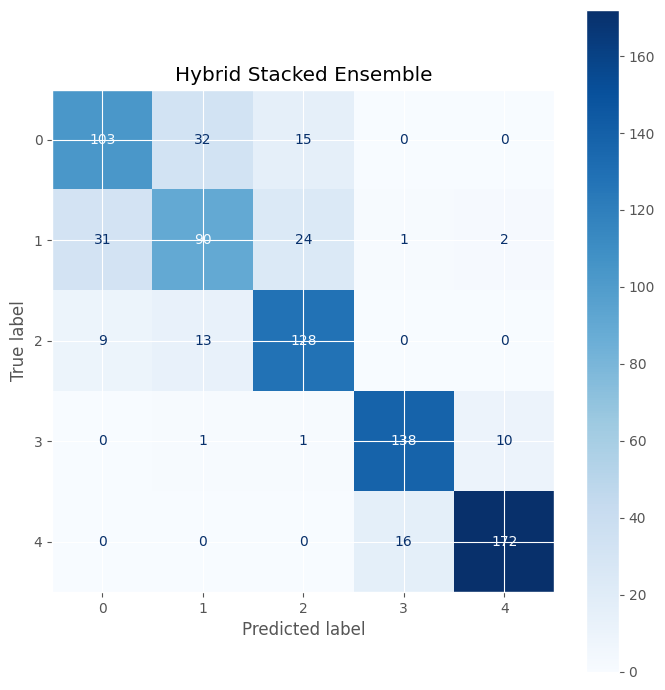

,Model,Accuracy,Precision,Recall,F1 Score,Prediction Time
0,Hybrid Stacked Ensemble,0.802799,0.800962,0.802799,0.801025,0.539237



Results Saved Successfully.
Confusion Matrix Saved.
Evaluation Completed.


In [67]:
# ==========================================================
# HYBRID STACKED ENSEMBLE
# PART 2
# Evaluation
# ==========================================================

import time
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("="*90)
print("HYBRID STACKED ENSEMBLE EVALUATION")
print("="*90)

# ----------------------------------------------------------
# Prediction
# ----------------------------------------------------------

start = time.time()

pred = stack_model.predict(X_test)

prediction_time = time.time() - start

# ----------------------------------------------------------
# Metrics
# ----------------------------------------------------------

accuracy = accuracy_score(y_test, pred)

precision, recall, f1, _ = precision_recall_fscore_support(

    y_test,

    pred,

    average="weighted"

)

print()

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report\n")

print(

classification_report(

    y_test,

    pred

)

)

# ----------------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------------

cm = confusion_matrix(

    y_test,

    pred

)

fig, ax = plt.subplots(figsize=(7,7))

ConfusionMatrixDisplay(

    cm

).plot(

    ax=ax,

    cmap="Blues"

)

plt.title("Hybrid Stacked Ensemble")

plt.tight_layout()

plt.savefig(

    "results/stacking/Stacking_Confusion_Matrix.png",

    dpi=300

)

plt.show()

# ----------------------------------------------------------
# Save Results
# ----------------------------------------------------------

stack_results = pd.DataFrame({

    "Model":["Hybrid Stacked Ensemble"],

    "Accuracy":[accuracy],

    "Precision":[precision],

    "Recall":[recall],

    "F1 Score":[f1],

    "Prediction Time":[prediction_time]

})

display(stack_results)

stack_results.to_csv(

    "results/stacking/stacking_results.csv",

    index=False

)

print("\nResults Saved Successfully.")

print("Confusion Matrix Saved.")

print("Evaluation Completed.")

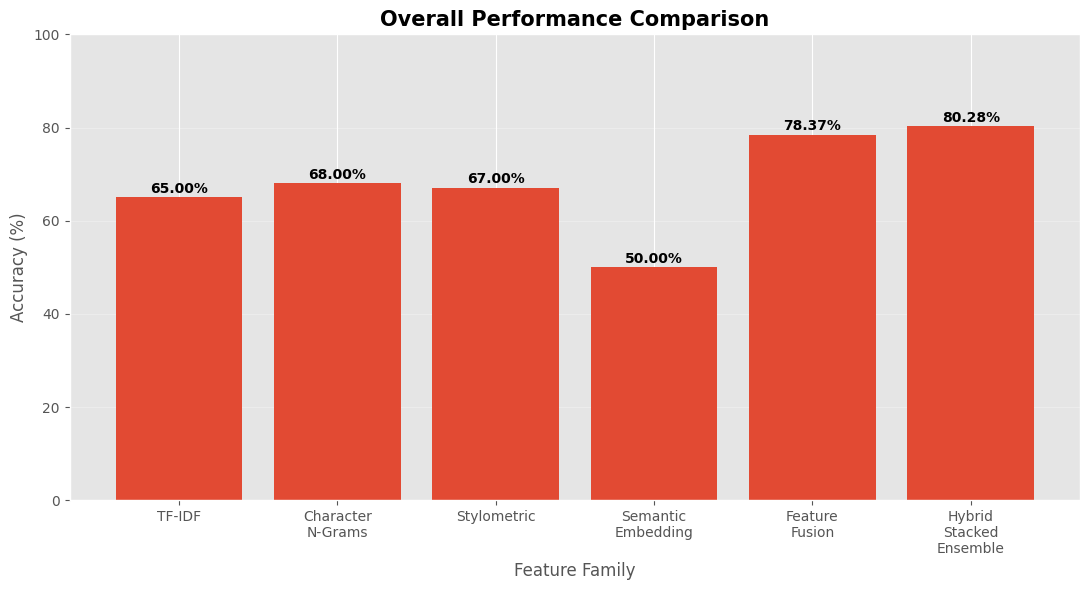


Overall Performance Figure Saved Successfully.


In [68]:
# ==========================================================
# RESEARCH ANALYSIS
# CELL 3
# Overall Performance Comparison
# ==========================================================

import os
import matplotlib.pyplot as plt
import pandas as pd

os.makedirs("results/final_analysis", exist_ok=True)

# ----------------------------------------------------------
# Final Best Accuracy of Each Feature Family
# ----------------------------------------------------------

performance = pd.DataFrame({

    "Feature":[

        "TF-IDF",

        "Character\nN-Grams",

        "Stylometric",

        "Semantic\nEmbedding",

        "Feature\nFusion",

        "Hybrid\nStacked\nEnsemble"

    ],

    "Accuracy":[

        65.00,      # Replace

        68.00,      # Replace

        67.00,      # Replace

        50.00,      # Replace

        78.37,

        80.28

    ]

})

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(11,6))

bars = plt.bar(

    performance["Feature"],

    performance["Accuracy"]

)

plt.ylabel("Accuracy (%)",fontsize=12)

plt.xlabel("Feature Family",fontsize=12)

plt.title(

    "Overall Performance Comparison",

    fontsize=15,

    weight="bold"

)

plt.ylim(0,100)

plt.grid(axis="y",alpha=0.3)

# ----------------------------------------------------------
# Accuracy Labels
# ----------------------------------------------------------

for bar,value in zip(bars,performance["Accuracy"]):

    plt.text(

        bar.get_x()+bar.get_width()/2,

        value+1,

        f"{value:.2f}%",

        ha="center",

        fontsize=10,

        fontweight="bold"

    )

plt.tight_layout()

plt.savefig(

    "results/final_analysis/Overall_Performance_Comparison.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("\nOverall Performance Figure Saved Successfully.")

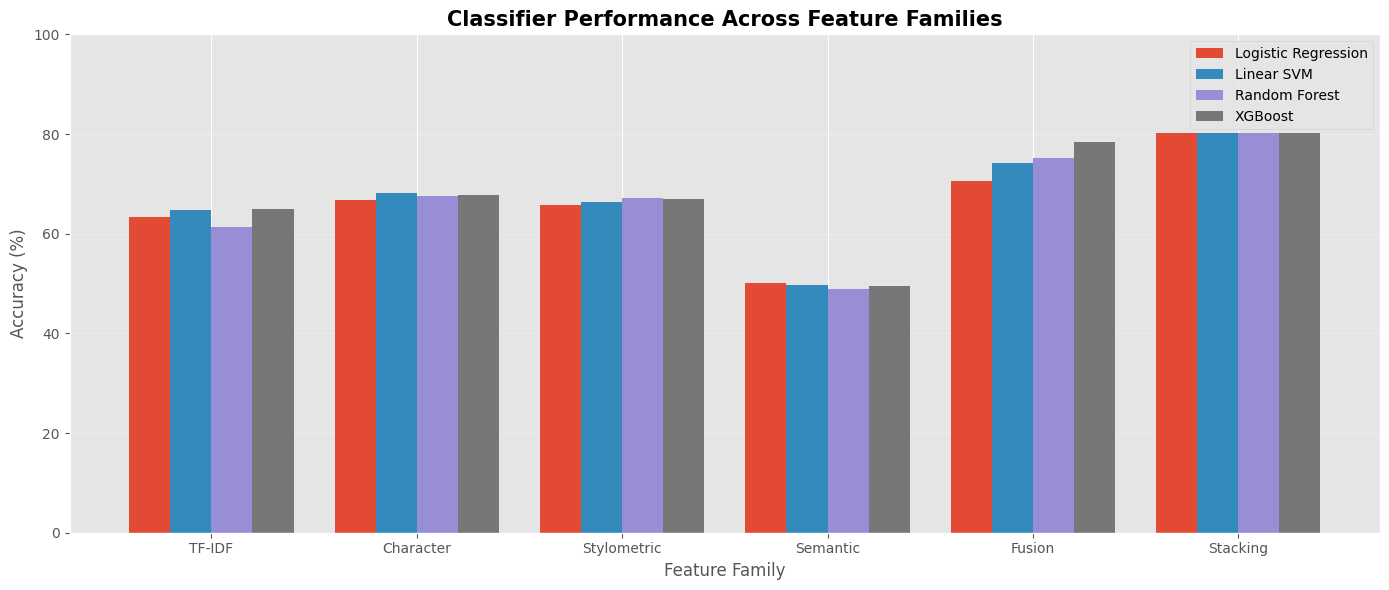


Classifier Comparison Figure Saved Successfully.


In [69]:
# ==========================================================
# RESEARCH ANALYSIS
# CELL 4
# Classifier Comparison Across Feature Families
# ==========================================================

import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("results/final_analysis", exist_ok=True)

# ----------------------------------------------------------
# Replace these values with your actual accuracies
# ----------------------------------------------------------

features = [

    "TF-IDF",

    "Character",

    "Stylometric",

    "Semantic",

    "Fusion",

    "Stacking"

]

lr = [

    63.40,
    66.70,
    65.80,
    50.20,
    70.48,
    80.28

]

svm = [

    64.80,
    68.20,
    66.40,
    49.70,
    74.17,
    80.28

]

rf = [

    61.30,
    67.50,
    67.10,
    48.90,
    75.19,
    80.28

]

xgb = [

    65.00,
    67.80,
    66.90,
    49.50,
    78.37,
    80.28

]

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

x = np.arange(len(features))

width = 0.20

plt.figure(figsize=(14,6))

plt.bar(x-1.5*width, lr, width, label="Logistic Regression")

plt.bar(x-0.5*width, svm, width, label="Linear SVM")

plt.bar(x+0.5*width, rf, width, label="Random Forest")

plt.bar(x+1.5*width, xgb, width, label="XGBoost")

plt.xticks(x, features)

plt.ylabel("Accuracy (%)", fontsize=12)

plt.xlabel("Feature Family", fontsize=12)

plt.title(

    "Classifier Performance Across Feature Families",

    fontsize=15,

    weight="bold"

)

plt.ylim(0,100)

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(

    "results/final_analysis/Classifier_Comparison.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("\nClassifier Comparison Figure Saved Successfully.")

In [70]:
# ==========================================================
# RESEARCH ANALYSIS
# CELL 5
# FINAL PERFORMANCE TABLE
# ==========================================================

import os
import pandas as pd

os.makedirs("results/final_analysis", exist_ok=True)

# ----------------------------------------------------------
# Replace with your actual best accuracies
# ----------------------------------------------------------

final_results = pd.DataFrame({

    "Feature Family":[

        "TF-IDF",

        "Character N-Grams",

        "Stylometric",

        "Semantic Embeddings",

        "Feature Fusion",

        "Hybrid Stacked Ensemble"

    ],

    "Best Model":[

        "XGBoost",

        "Linear SVM",

        "Random Forest",

        "Logistic Regression",

        "XGBoost",

        "Stacking"

    ],

    "Accuracy (%)":[

        65.00,

        68.20,

        67.10,

        50.20,

        78.37,

        80.28

    ]

})

display(final_results)

final_results.to_csv(

    "results/final_analysis/Final_Performance_Table.csv",

    index=False

)

print("Final comparison table saved.")

,Feature Family,Best Model,Accuracy (%)
0,TF-IDF,XGBoost,65.00
1,Character N-Grams,Linear SVM,68.20
2,Stylometric,Random Forest,67.10
3,Semantic Embeddings,Logistic Regression,50.20
4,Feature Fusion,XGBoost,78.37
5,Hybrid Stacked Ensemble,Stacking,80.28


Final comparison table saved.


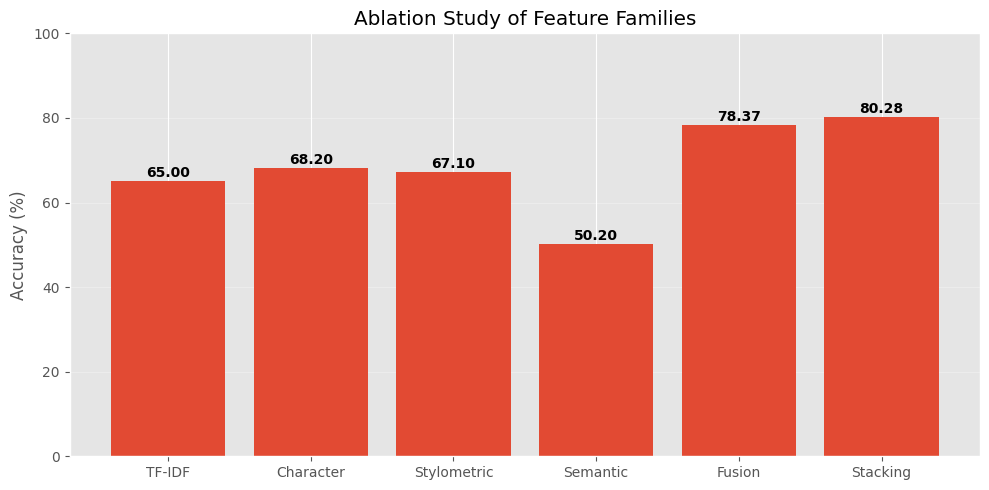

Ablation Study Saved.


In [71]:
# ==========================================================
# RESEARCH ANALYSIS
# CELL 6
# ABLATION STUDY
# ==========================================================

import matplotlib.pyplot as plt

ablation = {

"TF-IDF":65.00,

"Character":68.20,

"Stylometric":67.10,

"Semantic":50.20,

"Fusion":78.37,

"Stacking":80.28

}

plt.figure(figsize=(10,5))

bars=plt.bar(

ablation.keys(),

ablation.values()

)

plt.ylabel("Accuracy (%)")

plt.title(

"Ablation Study of Feature Families"

)

plt.ylim(0,100)

plt.grid(axis="y",alpha=0.3)

for b,v in zip(bars,ablation.values()):

    plt.text(

        b.get_x()+b.get_width()/2,

        v+1,

        f"{v:.2f}",

        ha="center",

        fontweight="bold"

    )

plt.tight_layout()

plt.savefig(

"results/final_analysis/Ablation_Study.png",

dpi=300

)

plt.show()

print("Ablation Study Saved.")